In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
#mpl.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
sns.set_style("white")
sns.set_style("ticks") 
from scipy.stats import sem
from scipy.stats import tstd
from sklearn.preprocessing import minmax_scale

import matlab.engine
eng = matlab.engine.start_matlab()

from sklearn.linear_model import LinearRegression
import json

In [2]:
def extract_frameTimes_from_metadata(metadata_filename):
    frameTimes = []
    with open(metadata_filename, "r") as metadata:
        for line in metadata:
            pieces = line.split(":")
            if len(pieces) < 2:
                continue
            else:
                if eval(pieces[0].strip()) == "Time":
                    hour = int(pieces[1].split()[-1])
                    #print(hour
                    minute = int(pieces[2])
                    #print(minute
                    second = int(pieces[3].split()[0])
                    #print(second
                    ms = int(pieces[3].split('-')[1].strip().strip(',').strip('"'))
                    #print(ms
                    converted_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
                    #print(converted_time
                    frameTimes.append(converted_time)
    metadata.close()
    return frameTimes

def extract_temps_times_from_metadata(stim_filename):
    Stim_data = {}
    Stim_data['Temp'] = []
    Stim_data['Time'] = []
    with open(stim_filename, "r") as stim:
        if '/' in stim_filename:
            stim_filename = stim_filename.split('/')[-1]
            
        rep_to_time = stim_filename.split(".txt")[0].split("_")
        hour = int(rep_to_time[1][0]+rep_to_time[1][1])
        minute = int(rep_to_time[1][2]+rep_to_time[1][3])
        #second = int(rep_to_time[1][4]+rep_to_time[1][5])
        #ms = int(rep_to_time[2])
        #starting_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
        hour_min = (hour*60*60*1000)+(minute*60*1000)

        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            #print(line
            pieces = line.split("\t")
            if len(pieces) < 2 or len(pieces) > 4:
                continue
            else:
                Stim_data['Temp'].append(float(pieces[0]))

                sec = int(pieces[3].split(".")[0])
                ms = int(pieces[3].split(".")[1])
                elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                
                if (hour_min+elapsed_time) >= 86400000:
                    midnight_crossing = hour_min+elapsed_time
                    elapsed_time = midnight_crossing - 86400000
                    elapsed_time_check = -1
                    hour_min = 0
                    elapsed_min = 0

                if elapsed_time > elapsed_time_check:
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                elif elapsed_time <= elapsed_time_check:
                    elapsed_min += 1
                    elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                else:
                    print('issue, something wrong')
    stim.close()
    return Stim_data

def align_Ca_to_stim(GCaMP_array, RFP_array, frameTimes, Stim):
    Stim_aligned_data = {}
    Stim_aligned_data['GCaMP'] = np.zeros((len(GCaMP_array),len(Stim['Time'])))
    Stim_aligned_data['RFP'] = np.zeros((len(RFP_array),len(Stim['Time'])))
    Stim_aligned_data['Time'] = []
    Stim_aligned_data['Temp'] = Stim['Temp']
    check = 1
    midnight_checker = 0
    for i in range(len(Stim['Time'])):
        if Stim['Time'][i-1] > 86340000 and Stim['Time'][i] < 60000 and midnight_checker == 0:
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
            midnight_checker = 1
        elif midnight_checker == 1: 
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
        else:
            Stim_aligned_data['Time'].append(Stim['Time'][i]-Stim['Time'][0])
        if Stim['Time'][i] > max(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,(len(GCaMP_array[j,:])-1)]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,(len(RFP_array[j,:])-1)]
            print('missed end')
        elif Stim['Time'][i] < min(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,0]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,0]
            print('missed start')
        else:
            for j in range(check, len(frameTimes)):
                if frameTimes[j-1] < Stim['Time'][i] <= frameTimes[j]:
                    for k in range(len(GCaMP_array)):
                        Stim_aligned_data['GCaMP'][k,i] = GCaMP_array[k,j]
                        Stim_aligned_data['RFP'][k,i] = RFP_array[k,j]
                    check = j
                    break
    return Stim_aligned_data

def ratio_and_scale(GCaMP_Array, RFP_Array, RFP_check=True):
    Ratio = np.zeros(np.shape(GCaMP_Array))
    Scaled = np.zeros(np.shape(GCaMP_Array))
    Delta = np.zeros(np.shape(GCaMP_Array))
    
    if RFP_check == True:
        for i in range(len(GCaMP_Array)):
            for j in range(len(GCaMP_Array[i,:])):
                Ratio[i,j] = GCaMP_Array[i,j]/RFP_Array[i,j]
            min_rat = min(Ratio[i,:])
            for j in range(len(Ratio[i,:])):
                Delta[i,j] = (Ratio[i,j] - min_rat)/float(min_rat)
            Scaled[i,:] = minmax_scale(Ratio[i,:], feature_range=(0, 1))
    elif RFP_check == False:
        for i in range(len(GCaMP_Array)):
            Scaled[i,:] = minmax_scale(GCaMP_Array[i,:], feature_range=(0, 1))
            min_gcamp = min(GCaMP_Array[i,:])
            for j in range(len(GCaMP_Array[i,:])):
                Delta[i,j] = (GCaMP_Array[i,j] - min_gcamp)/float(min_gcamp)
    else:
        print('issue Scaling')
        
    return Delta, Scaled

def find_temp_transition(Stim_aligned_data, start_search, temp_thresh):
    for i in reversed(range(start_search)):
        if Stim_aligned_data['Temp'][i]>=temp_thresh:
            start_index = i
            break
    #print(start_index)
    return start_index

def segment_data(Stim_aligned_data, start_index, stop_index, AIY=False):
    Segmented_data = {}
    Segmented_data['GCaMP'] = Stim_aligned_data['GCaMP'][:,start_index:stop_index]
    Segmented_data['RFP'] = Stim_aligned_data['RFP'][:,start_index:stop_index]
    Segmented_data['Scaled'] = Stim_aligned_data['Scaled'][:,start_index:stop_index]
    Segmented_data['Time'] = []
    for i in range(len(Stim_aligned_data['Time'][start_index:stop_index])):
        Segmented_data['Time'].append(Stim_aligned_data['Time'][start_index+i]-Stim_aligned_data['Time'][start_index])
    Segmented_data['Temp'] = Stim_aligned_data['Temp'][start_index:stop_index]
    
    if AIY == True:
        Segmented_data['Resp_Rate'] = Stim_aligned_data['Resp_Rate'][:,start_index:stop_index]
        Segmented_data['Resp'] = Stim_aligned_data['Resp'][:,start_index:stop_index]
    
    return Segmented_data

def combine_segments_calc_stats(Segment_list, AIY=False):
    Combined_data = {}
    Combined_data['GCaMP'] = np.concatenate([Seg_dict['GCaMP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['RFP'] = np.concatenate([Seg_dict['RFP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Scaled'] = np.concatenate([Seg_dict['Scaled'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Delta'] = np.concatenate([Seg_dict['Delta'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Mean'] = []
    Combined_data['Std_high'] = []
    Combined_data['Std_low'] = []
    Combined_data['Mean_Delta'] = []
    Combined_data['Std_high_Delta'] = []
    Combined_data['Std_low_Delta'] = []
    for i in range(len(Combined_data['Scaled'][0,:])):
        Combined_data['Mean'].append(np.mean(Combined_data['Scaled'][:,i]))
        Combined_data['Std_high'].append(np.mean(Combined_data['Scaled'][:,i])+tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Std_low'].append(np.mean(Combined_data['Scaled'][:,i])-tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Mean_Delta'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Delta'].append(np.mean(Combined_data['Delta'][:,i])+tstd(Combined_data['Delta'][:,i]))
        Combined_data['Std_low_Delta'].append(np.mean(Combined_data['Delta'][:,i])-tstd(Combined_data['Delta'][:,i]))
    Combined_data['Time'] = []
    Combined_data['Temp'] = []
    for i in range(len(Segment_list[0]['Time'])):
        time_total_dum = 0
        time_count_dum = 0
        temp_total_dum = 0
        temp_count_dum = 0
        for j in range(len(Segment_list)):
            time_total_dum += Segment_list[j]['Time'][i]*len(Segment_list[j]['GCaMP'])
            time_count_dum += len(Segment_list[j]['GCaMP'])
            temp_total_dum += Segment_list[j]['Temp'][i]*len(Segment_list[j]['GCaMP'])
            temp_count_dum += len(Segment_list[j]['GCaMP'])
        Combined_data['Time'].append(time_total_dum/(time_count_dum*1000))
        Combined_data['Temp'].append(temp_total_dum/temp_count_dum)
        
    if AIY == True:
        Combined_data['Resp'] = np.concatenate([Seg_dict['Resp'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Resp_Rate'] = np.concatenate([Seg_dict['Resp_Rate'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Mean_Resp_Rate'] = []
        for i in range(len(Combined_data['Resp_Rate'][0,:])):
            Combined_data['Mean_Resp_Rate'].append(np.mean(Combined_data['Resp_Rate'][:,i]))
            
    return Combined_data

def load_GCaMP_RFP_meta_stim(Rep_list, stim_list, cell , RFP_check=True):
    Aligned_data_list = []
    for i in range(len(Rep_list)):
        Rep_name = Rep_list[i]
        stim_name = stim_list[i]
        print(Rep_name)
        GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_Results.csv', header=None)))
        if RFP_check==True:
            RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_Results_RFP.csv', header=None)))
        elif RFP_check==False:
            RFP = np.zeros(np.shape(GCaMP))

        frameTimes = extract_frameTimes_from_metadata(Rep_name+'_MMStack_Pos0_metadata.txt')
        #print(frameTimes[0:10]
        Stim = extract_temps_times_from_metadata(stim_name+'.txt')
        #print(Stim['Time'][0:10]

        Aligned_data = align_Ca_to_stim(GCaMP, RFP, frameTimes, Stim)
        Aligned_data['Delta'], Aligned_data['Scaled'] = ratio_and_scale(Aligned_data['GCaMP'], Aligned_data['RFP'], RFP_check=RFP_check)

        if cell == 'AIY':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)

        if cell == 'AIY_Paired':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)
        
        Aligned_data_list.append(Aligned_data)
        print('Done')
        
    if cell == 'AFD':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list)
        Aligned_data_Combined['Deriv'], Aligned_data_Combined['Response_frame'], Aligned_data_Combined['Response_temp'] = find_AFD_deriv_and_response_thresh(Aligned_data_Combined)
    elif cell == 'AIY':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list, AIY=True)
        
    return Aligned_data_Combined

def calc_AIY_responses(Scaled_data, threshold = 0.05, window = 300, back=True):
    AIY_Deriv = np.zeros(np.shape(Scaled_data))
    AIY_Response = np.zeros(np.shape(Scaled_data))
    AIY_Resp_Rate = np.zeros(np.shape(Scaled_data))
        
        
    for i in range(len(Scaled_data)):
        AIY_Deriv[i,1:] = np.diff(Scaled_data[i,:])

        check = 0
        for j in range(len(AIY_Deriv[i,:])):
            if AIY_Deriv[i,j] > threshold and check == 0:
                AIY_Response[i,j] = 1
                check = 1
            elif AIY_Deriv[i,j] < threshold and check == 1:
                check = 0
            else:
                continue

        for j in range(len(AIY_Response[i,:])):
            if back == True:
                if j-(2*window) < 0:
                    #Tc20_Combined['AIY'][key]['Resp_Rate'][i,j] = np.sum(Tc20_Combined['AIY'][key]['Response'][i,0:j])*60/float(j/10)
                    AIY_Resp_Rate[i,j] = np.nan
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-(2*window):j])
            else:
                if j-window < 0:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,0:j+window])*60/float((j+window)*60/10)
                elif j+window > len(AIY_Response[i,:]):
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:])
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:j+window])

        #Tc20_Combined['AIY'][key]['Mean_Resp_Rate'] = []
        #for i in range(len(Tc20_Combined['AIY'][key]['Resp_Rate'][0,:])):
        #    Tc20_Combined['AIY'][key]['Mean_Resp_Rate'].append(np.mean(Tc20_Combined['AIY'][key]['Resp_Rate'][:,i]))
            
    return AIY_Response, AIY_Resp_Rate

def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 600):
    Deriv = [0]
    Deriv.extend(list(np.diff(AFD_data['Mean'])))
    for i in range(len(Deriv[start_frame:])):
        if Deriv[start_frame+i] > threshold:
            Response_frame = start_frame+i
            Response_temp = AFD_data['Temp'][Response_frame]
            break
    return Deriv, Response_frame, Response_temp

# Load VR Realistic Stim

In [ ]:
pref = 'VR_Naturalistic_with_Downshift_Stim/Data/'
Tc25_meta = [pref + '012921_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1', pref + '012921_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_C_1',\
             pref + '020121_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1', pref + '020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1',\
             pref + '020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_B_1']
Tc25_stim = [pref + '012921_131800_361', pref + '012921_143813_312',\
             pref + '020121_141302_387', pref + '020221_190414_857',\
             pref + '020221_194305_365']

Tc25 = load_GCaMP_RFP_meta_stim(Tc25_meta, Tc25_stim, 'AFD')

VR_Naturalistic_with_Downshift_Stim/Data/012921_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/012921_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_C_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020121_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc25_B_1
Done


In [4]:
pref = 'VR_Naturalistic_with_Downshift_Stim/Data/'
Tc20_meta = [pref + '020121_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1', pref + '020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1',\
             pref + '020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1', pref + '021321_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_2',\
            pref + '021621_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1']
Tc20_stim = [pref + '020121_125318_431', pref + '020221_141802_628',\
             pref + '020221_145424_782', pref + '021321_145851_008',\
            pref + '021621_143716_857']

Tc20 = load_GCaMP_RFP_meta_stim(Tc20_meta, Tc20_stim, 'AFD')


Tc20_DOWN3_meta = [pref + '022221_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1', pref + '022221_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1',\
                   pref + '030621_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1', pref + '031121_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1']
Tc20_DOWN3_stim = [pref + '022221_141303_320', pref + '022221_145106_183', pref + '030621_120903_893', pref + '031121_133928_928']

Tc20_DOWN3 = load_GCaMP_RFP_meta_stim(Tc20_DOWN3_meta, Tc20_DOWN3_stim, 'AFD')
    

Tc15_meta = [pref + '032521_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc15_A_1', pref + '032521_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc15_B_1',\
             pref + '032521_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc15_C_1']
Tc15_stim = [pref + '032521_123037_660',pref + '032521_130611_906',pref + '032521_134700_950']

Tc15 = load_GCaMP_RFP_meta_stim(Tc15_meta, Tc15_stim, 'AFD')

VR_Naturalistic_with_Downshift_Stim/Data/020121_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/020221_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/021321_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_2
Done
VR_Naturalistic_with_Downshift_Stim/Data/021621_3055_8223_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/022221_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_A_1
missed start
missed start
Done
VR_Naturalistic_with_Downshift_Stim/Data/022221_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1
Done
VR_Naturalistic_with_Downshift_Stim/Data/030621_3055_8223_3DEGDOWN_Hold20_plus_Natur_plus_Natur2_plus_Hold24p5_Tc20_B_1
Done
VR_Naturalistic_wit

In [5]:
print( len(Tc25['GCaMP'])
, len(Tc20['GCaMP'])
, len(Tc20_DOWN3['GCaMP'])
, len(Tc15['GCaMP']) )

21 24 27 13


# Tc25 Stimulus VR

<Figure size 640x480 with 0 Axes>

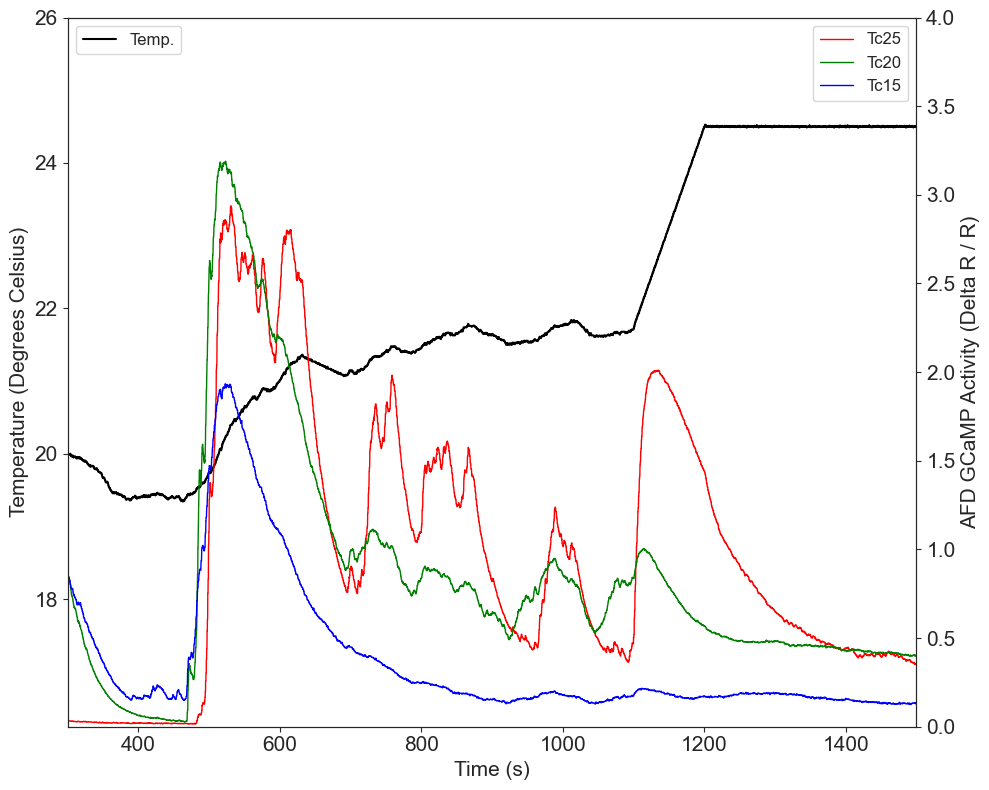

In [6]:
plt.clf()

fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))
ax1 = plt.subplot(1,1,1)
ax1.plot(Tc25['Time'][3000:], Tc25['Temp'][3000:], 'k')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(min(Tc25['Time']),max(Tc25['Time']))
ax1.legend(labels=['Temp.'], fontsize = 12, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(Tc25['Time'][3000:], Tc25['Mean_Delta'][3000:], 'r', lw=1)
ax2.plot(Tc20['Time'][3000:], Tc20['Mean_Delta'][3000:], 'g', lw=1)
ax2.plot(Tc15['Time'][3000:], Tc15['Mean_Delta'][3000:], 'b', lw=1)
ax2.legend(labels=['Tc25', 'Tc20', 'Tc15'], fontsize = 12, loc='upper right')
ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(min(Tc25['Time'][3000:]),max(Tc25['Time']))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#plt.savefig('VR_Tc25_Stim.png', dpi=600, bbox_inches='tight')
#plt.savefig('VR_Tc25_Stim.svg', dpi=600, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

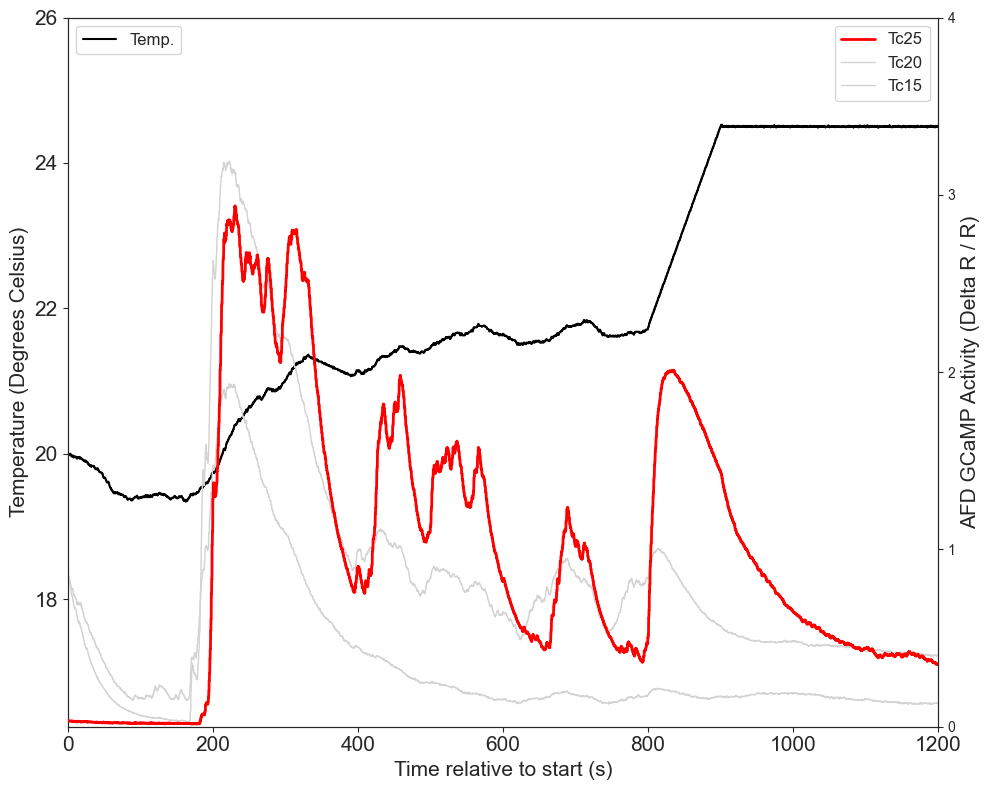

<Figure size 640x480 with 0 Axes>

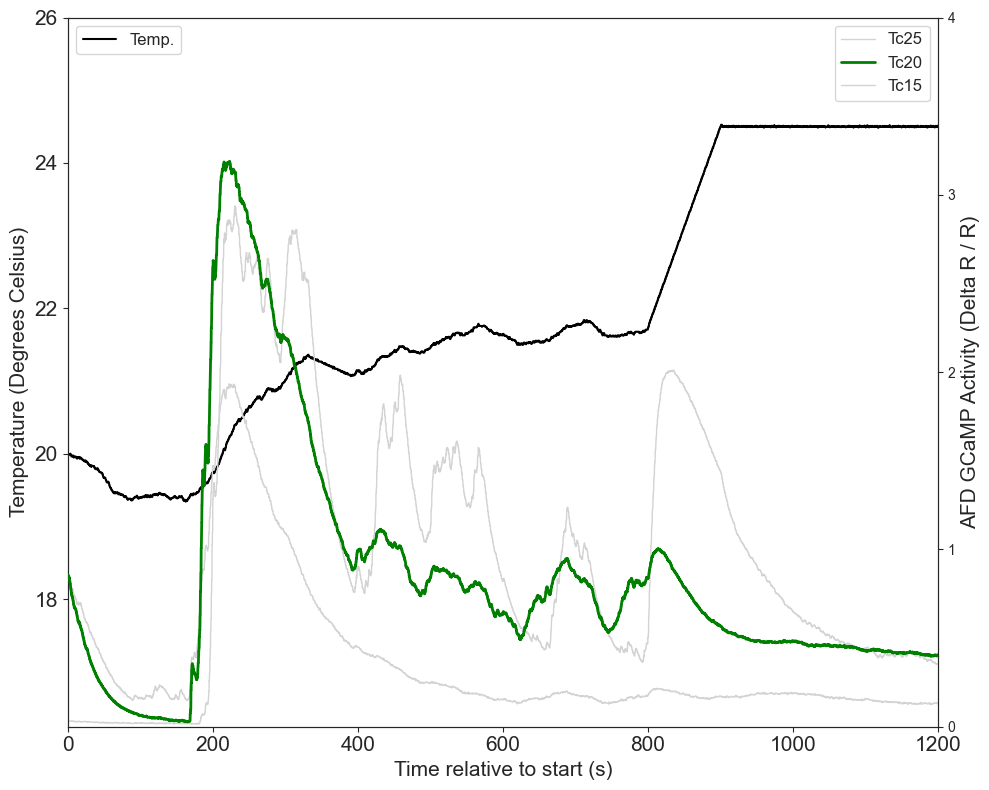

<Figure size 640x480 with 0 Axes>

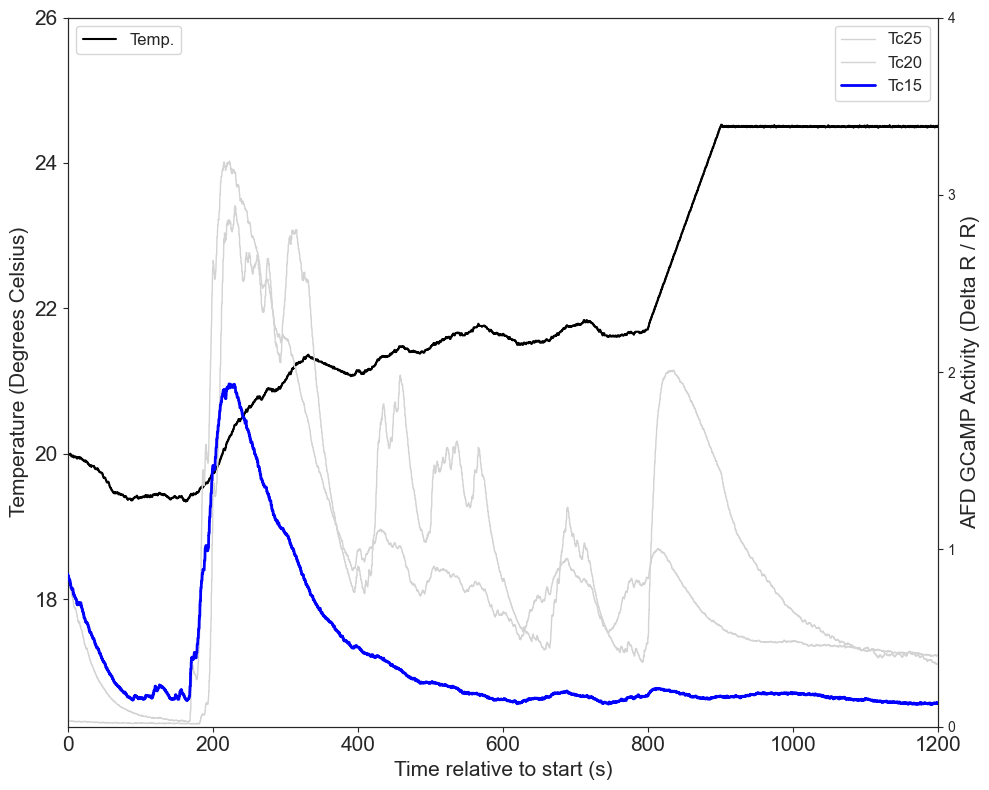

In [7]:
conditions = [
    {'data': Tc25, 'label': 'Tc25', 'color': 'r'},
    {'data': Tc20, 'label': 'Tc20', 'color': 'g'},
    {'data': Tc15, 'label': 'Tc15', 'color': 'b'}
]

for highlight_idx in range(3):
    plt.clf()
    fig, ax1 = plt.subplots(figsize=(10, 8))
    
    # --- 1. CALCULATE RELATIVE TIME ---
    # We define t=0 as the time at index 3000
    t_start = Tc25['Time'][3000]
    relative_time_full = [t - t_start for t in Tc25['Time'][3000:]]

    # Plot Temperature using the new relative scale
    ax1.plot(relative_time_full, Tc25['Temp'][3000:], 'k', label='Temp.')
    
    ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
    ax1.set_xlabel('Time relative to start (s)', fontsize=15) # Updated label
    ax1.set_ylim(16.25, 26)
    ax1.set_xlim(0, max(relative_time_full)) # Start axis at 0
    ax1.legend(loc='upper left', fontsize=12)
    plt.tick_params(axis='both', labelsize=15)

    ax2 = ax1.twinx()
    
    # --- 2. PLOT CALCIUM TRACES ---
    for i, cond in enumerate(conditions):
        current_color = cond['color'] if i == highlight_idx else 'lightgray'
        current_lw = 2 if i == highlight_idx else 1
        current_zorder = 5 if i == highlight_idx else 1
        
        # Calculate relative time for each specific condition
        t_start_cond = cond['data']['Time'][3000]
        rel_time_cond = [t - t_start_cond for t in cond['data']['Time'][3000:]]
        
        ax2.plot(rel_time_cond, 
                 cond['data']['Mean_Delta'][3000:], 
                 color=current_color, 
                 lw=current_lw, 
                 zorder=current_zorder,
                 label=cond['label'])

    ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize=15)
    ax2.set_ylim(0, 4.0)
    ax2.set_yticks([0, 1, 2, 3, 4])
    ax2.set_xlim(0, max(relative_time_full))
    ax2.legend(loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    plt.close()

<Figure size 640x480 with 0 Axes>

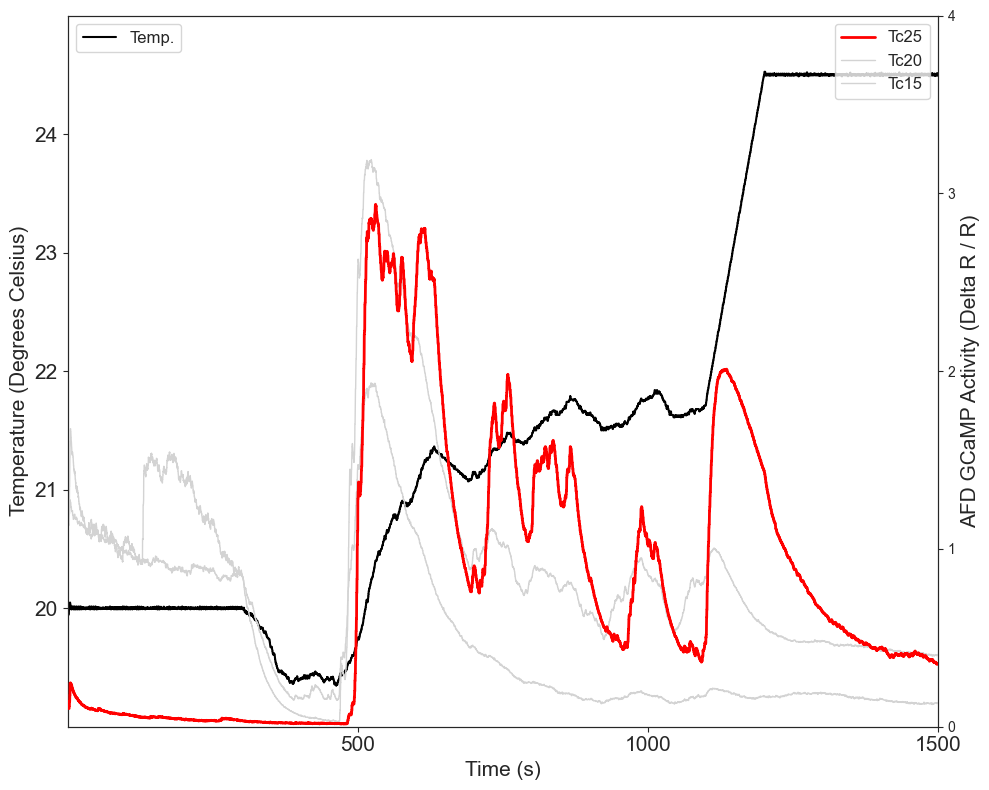

<Figure size 640x480 with 0 Axes>

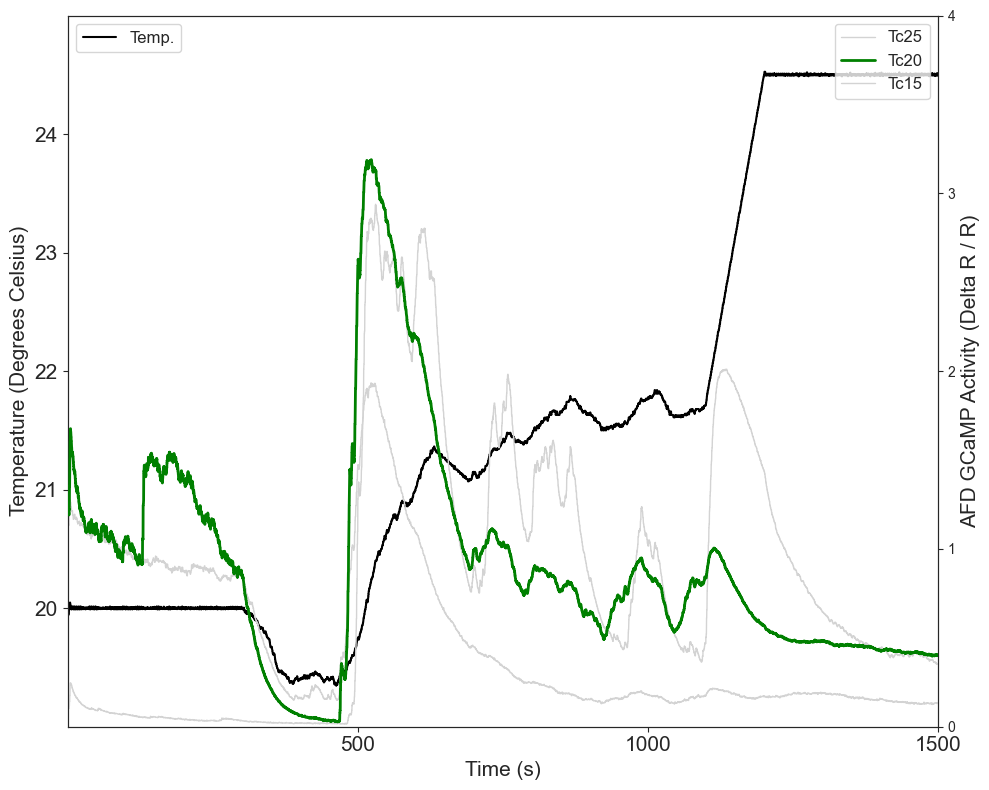

<Figure size 640x480 with 0 Axes>

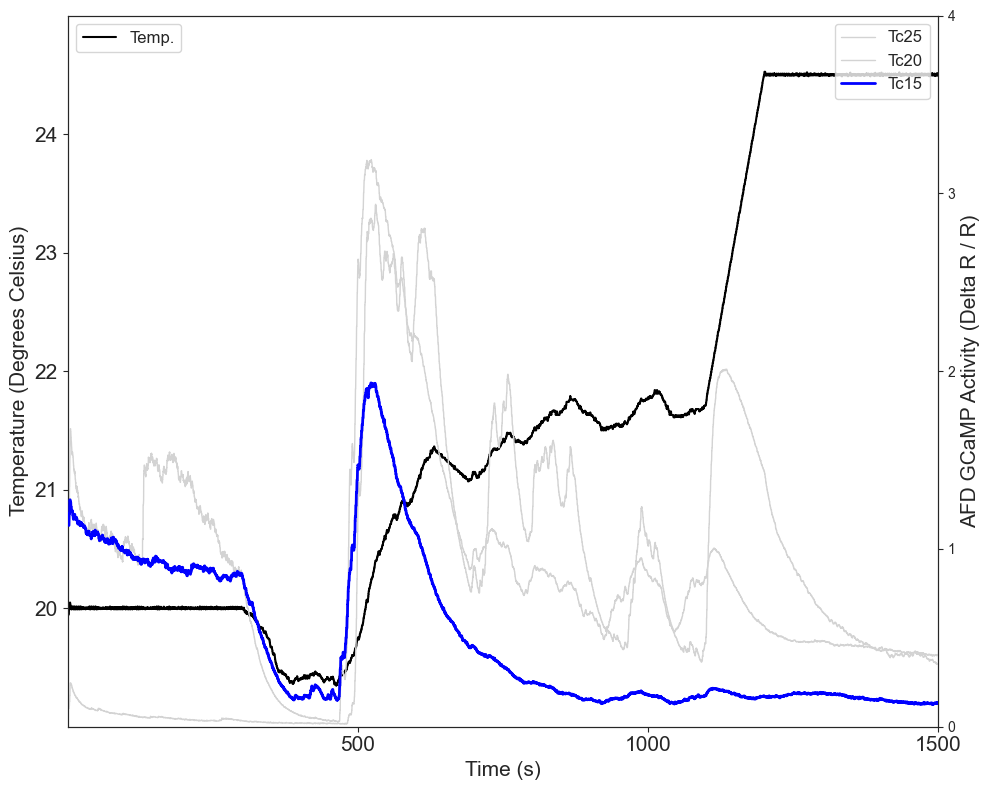

In [8]:
conditions = [
    {'data': Tc25, 'label': 'Tc25', 'color': 'r'},
    {'data': Tc20, 'label': 'Tc20', 'color': 'g'},
    {'data': Tc15, 'label': 'Tc15', 'color': 'b'}
]

for highlight_idx in range(3):
    plt.clf()
    fig, ax1 = plt.subplots(figsize=(10, 8))
    
    # --- 1. PLOT TEMPERATURE ---
    # Using original timestamps from the data slice starting at index 3000
    ax1.plot(Tc25['Time'], Tc25['Temp'], 'k', label='Temp.')
    
    ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
    ax1.set_xlabel('Time (s)', fontsize=15) 
    ax1.set_ylim(19, 25)
    ax1.set_xticks([500, 1000, 1500]) 
    # Set X-limits to the original timestamp range
    t_min = min(Tc25['Time'])
    t_max = max(Tc25['Time'])
    ax1.set_xlim(t_min, t_max)  
    ax1.set_yticks([20,21,22,23,24])
    ax1.legend(loc='upper left', fontsize=12)
    plt.tick_params(axis='both', labelsize=15)

    ax2 = ax1.twinx()
    
    # --- 2. PLOT CALCIUM TRACES ---
    for i, cond in enumerate(conditions):
        current_color = cond['color'] if i == highlight_idx else 'lightgray'
        current_lw = 2 if i == highlight_idx else 1
        current_zorder = 5 if i == highlight_idx else 1
        
        # Use standard time for each condition
        ax2.plot(cond['data']['Time'], 
                 cond['data']['Mean_Delta'], 
                 color=current_color, 
                 lw=current_lw, 
                 zorder=current_zorder,
                 label=cond['label'])

    # --- 3. FORMATTING AX2 ---
    ax2.set_ylabel('AFD GCaMP Activity (Delta R / R)', fontsize=15)
    ax2.set_ylim(0, 4.0)
    
    # Set Y-axis to 0-4 in steps of 1
    ax2.set_yticks([0, 1, 2, 3, 4]) 
    
    ax2.set_xlim(t_min, t_max)
    ax2.legend(loc='upper right', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    plt.close()

# Tc25 Stimulus Downshifted VR

<Figure size 640x480 with 0 Axes>

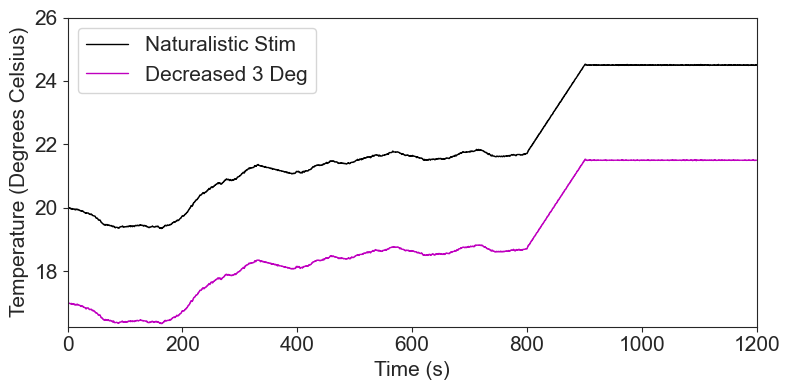

In [9]:
segment = 'seg4'
plt.clf()
fig = plt.subplots(nrows=1,ncols=1,figsize=(8,4))

ax1 = plt.subplot(1,1,1)
ax1.plot(relative_time_full, Tc25['Temp'][3000:], 'k', lw=1)
ax1.plot(relative_time_full, Tc20_DOWN3['Temp'][3000:], 'm', lw=1)
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(0, max(relative_time_full))
ax1.legend(labels=['Naturalistic Stim', 'Decreased 3 Deg'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()
#plt.savefig('VR_Tc25&DownshiftStims.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

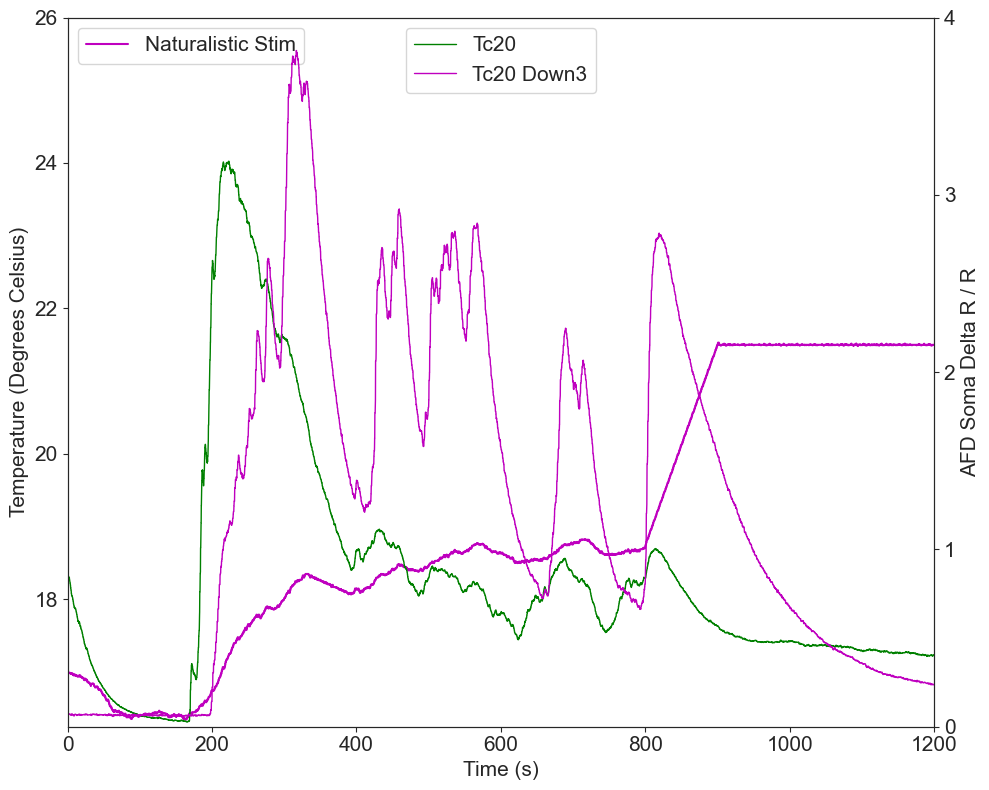

In [10]:
segment = 'seg4'
plt.clf()
fig = plt.subplots(nrows=1,ncols=1,figsize=(10,8))#,dpi=300)#plt.ylim(0,1)

ax1 = plt.subplot(1,1,1)
ax1.plot(relative_time_full, Tc20_DOWN3['Temp'][3000:], 'm')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize = 15)
ax1.set_xlabel('Time (s)', fontsize = 15)
ax1.set_ylim(16.25,26)
ax1.set_xlim(0, max(relative_time_full))
ax1.legend(labels=['Naturalistic Stim', 'Decreased 3 Deg'], fontsize = 15, loc='upper left')
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
ax2.plot(relative_time_full, Tc20['Mean_Delta'][3000:], 'g', lw=1)
ax2.plot(relative_time_full, Tc20_DOWN3['Mean_Delta'][3000:], 'm', lw=1)
ax2.legend(labels=['Tc20', 'Tc20 Down3'], fontsize = 15, loc='upper center')

ax2.set_ylabel('AFD Soma Delta R / R', fontsize = 15)
ax2.set_ylim(0,4.0)
ax2.set_xlim(0, max(relative_time_full))
ax2.set_yticks([0, 1, 2, 3, 4])
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)


plt.tight_layout()


#plt.savefig('VR_DownshiftStim.svg', dpi=600, bbox_inches='tight')

# SineUpramp Downshift

In [3]:
## JB convert times from metadata to elapsed time formula

def extract_frameTimes_from_metadata(metadata_filename):
    frameTimes = []
    
    with open(metadata_filename) as f:
        metadata = json.load(f)
    f.close()
    
    if int(metadata['Summary']['MicroManagerVersion'][0]) == 1:
        print('MicroManager v1')
        hour = int(metadata['FrameKey-0-0-0']['Time'][11:13])
        minute = int(metadata['FrameKey-0-0-0']['Time'][14:16])
        second = int(metadata['FrameKey-0-0-0']['Time'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)-int(metadata['FrameKey-0-0-0']['ElapsedTime-ms'])
    elif int(metadata['Summary']['MicroManagerVersion'][0]) > 1:
        print('MicroManager v2 or greater')
        hour = int(metadata['Summary']['StartTime'][11:13])
        minute = int(metadata['Summary']['StartTime'][14:16])
        second = int(metadata['Summary']['StartTime'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+int(metadata['Summary']['StartTime'][20:23])

    for i in range(len(metadata.keys())-1):
        frame_name = "FrameKey-"+str(i)+"-0-0"
        #print(frame_name, start_time + int(metadata[frame_name]['ElapsedTime-ms']))
        frameTimes.append(start_time + int(metadata[frame_name]['ElapsedTime-ms']))
            
    return frameTimes

def extract_temps_times_from_metadata(stim_filename):
    Stim_data = {}
    Stim_data['Temp'] = []
    Stim_data['Time'] = []
    with open(stim_filename, "r") as stim:
        if '/' in stim_filename:
            stim_filename = stim_filename.split('/')[-1]
            
        rep_to_time = stim_filename.split(".txt")[0].split("_")
        hour = int(rep_to_time[1][0]+rep_to_time[1][1])
        minute = int(rep_to_time[1][2]+rep_to_time[1][3])
        #second = int(rep_to_time[1][4]+rep_to_time[1][5])
        #ms = int(rep_to_time[2])
        #starting_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
        hour_min = (hour*60*60*1000)+(minute*60*1000)

        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            #print(line
            pieces = line.split("\t")
            if len(pieces) < 2 or len(pieces) > 4:
                continue
            else:
                Stim_data['Temp'].append(float(pieces[0]))

                sec = int(pieces[3].split(".")[0])
                ms = int(pieces[3].split(".")[1])
                elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                
                if (hour_min+elapsed_time) >= 86400000:
                    midnight_crossing = hour_min+elapsed_time
                    elapsed_time = midnight_crossing - 86400000
                    elapsed_time_check = -1
                    hour_min = 0
                    elapsed_min = 0

                if elapsed_time > elapsed_time_check:
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                elif elapsed_time <= elapsed_time_check:
                    elapsed_min += 1
                    elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                else:
                    print('issue, something wrong')
    stim.close()
    return Stim_data

def align_Ca_to_stim(GCaMP_array, RFP_array, frameTimes, Stim):
    Stim_aligned_data = {}
    Stim_aligned_data['GCaMP'] = np.zeros((len(GCaMP_array),len(Stim['Time'])))
    Stim_aligned_data['RFP'] = np.zeros((len(RFP_array),len(Stim['Time'])))
    Stim_aligned_data['Time'] = []
    Stim_aligned_data['Temp'] = Stim['Temp']
    check = 1
    midnight_checker = 0
    for i in range(len(Stim['Time'])):
        if Stim['Time'][i-1] > 86340000 and Stim['Time'][i] < 60000 and midnight_checker == 0:
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
            midnight_checker = 1
        elif midnight_checker == 1: 
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
        else:
            Stim_aligned_data['Time'].append(Stim['Time'][i]-Stim['Time'][0])
        if Stim['Time'][i] > max(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,(len(GCaMP_array[j,:])-1)]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,(len(RFP_array[j,:])-1)]
            print('missed end')
        elif Stim['Time'][i] < min(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,0]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,0]
            print('missed start')
        else:
            for j in range(check, len(frameTimes)):
                if frameTimes[j-1] < Stim['Time'][i] <= frameTimes[j]:
                    for k in range(len(GCaMP_array)):
                        Stim_aligned_data['GCaMP'][k,i] = GCaMP_array[k,j]
                        Stim_aligned_data['RFP'][k,i] = RFP_array[k,j]
                    check = j
                    break
    return Stim_aligned_data

def ratio_and_scale(GCaMP_Array, RFP_Array, RFP_check=True):
    Ratio = np.zeros(np.shape(GCaMP_Array))
    Scaled = np.zeros(np.shape(GCaMP_Array))
    Delta = np.zeros(np.shape(GCaMP_Array))
    
    if RFP_check == True:
        for i in range(len(GCaMP_Array)):
            for j in range(len(GCaMP_Array[i,:])):
                Ratio[i,j] = GCaMP_Array[i,j]/RFP_Array[i,j]
            min_rat = min(Ratio[i,:])
            for j in range(len(Ratio[i,:])):
                Delta[i,j] = (Ratio[i,j] - min_rat)/float(min_rat)
            Scaled[i,:] = minmax_scale(Ratio[i,:], feature_range=(0, 1))
    elif RFP_check == False:
        for i in range(len(GCaMP_Array)):
            Scaled[i,:] = minmax_scale(GCaMP_Array[i,:], feature_range=(0, 1))
            min_gcamp = min(GCaMP_Array[i,:])
            for j in range(len(GCaMP_Array[i,:])):
                Delta[i,j] = (GCaMP_Array[i,j] - min_gcamp)/float(min_gcamp)
    else:
        print('issue Scaling')
        
    return Delta, Scaled

def find_temp_transition(Stim_aligned_data, start_search, temp_thresh):
    for i in reversed(range(start_search)):
        if Stim_aligned_data['Temp'][i]>=temp_thresh:
            start_index = i
            break
    #print(start_index)
    return start_index

def segment_data(Stim_aligned_data, start_index, stop_index, AIY=False):
    Segmented_data = {}
    Segmented_data['GCaMP'] = Stim_aligned_data['GCaMP'][:,start_index:stop_index]
    Segmented_data['RFP'] = Stim_aligned_data['RFP'][:,start_index:stop_index]
    Segmented_data['Scaled'] = Stim_aligned_data['Scaled'][:,start_index:stop_index]
    Segmented_data['Time'] = []
    for i in range(len(Stim_aligned_data['Time'][start_index:stop_index])):
        Segmented_data['Time'].append(Stim_aligned_data['Time'][start_index+i]-Stim_aligned_data['Time'][start_index])
    Segmented_data['Temp'] = Stim_aligned_data['Temp'][start_index:stop_index]
    
    if AIY == True:
        Segmented_data['Resp_Rate'] = Stim_aligned_data['Resp_Rate'][:,start_index:stop_index]
        Segmented_data['Resp'] = Stim_aligned_data['Resp'][:,start_index:stop_index]
    
    return Segmented_data

def combine_segments_calc_stats(Segment_list, AIY=False):
    Combined_data = {}
    Combined_data['GCaMP'] = np.concatenate([Seg_dict['GCaMP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['RFP'] = np.concatenate([Seg_dict['RFP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Scaled'] = np.concatenate([Seg_dict['Scaled'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Delta'] = np.concatenate([Seg_dict['Delta'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Mean'] = []
    Combined_data['Std_high'] = []
    Combined_data['Std_low'] = []
    Combined_data['Mean_Delta'] = []
    Combined_data['Std_high_Delta'] = []
    Combined_data['Std_low_Delta'] = []
    for i in range(len(Combined_data['Scaled'][0,:])):
        Combined_data['Mean'].append(np.mean(Combined_data['Scaled'][:,i]))
        Combined_data['Std_high'].append(np.mean(Combined_data['Scaled'][:,i])+tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Std_low'].append(np.mean(Combined_data['Scaled'][:,i])-tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Mean_Delta'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Delta'].append(np.mean(Combined_data['Delta'][:,i])+tstd(Combined_data['Delta'][:,i]))
        Combined_data['Std_low_Delta'].append(np.mean(Combined_data['Delta'][:,i])-tstd(Combined_data['Delta'][:,i]))
    Combined_data['Time'] = []
    Combined_data['Temp'] = []
    for i in range(len(Segment_list[0]['Time'])):
        time_total_dum = 0
        time_count_dum = 0
        temp_total_dum = 0
        temp_count_dum = 0
        for j in range(len(Segment_list)):
            time_total_dum += Segment_list[j]['Time'][i]*len(Segment_list[j]['GCaMP'])
            time_count_dum += len(Segment_list[j]['GCaMP'])
            temp_total_dum += Segment_list[j]['Temp'][i]*len(Segment_list[j]['GCaMP'])
            temp_count_dum += len(Segment_list[j]['GCaMP'])
        Combined_data['Time'].append(time_total_dum/(time_count_dum*1000))
        Combined_data['Temp'].append(temp_total_dum/temp_count_dum)
        
    if AIY == True:
        Combined_data['Resp'] = np.concatenate([Seg_dict['Resp'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Resp_Rate'] = np.concatenate([Seg_dict['Resp_Rate'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Mean_Resp_Rate'] = []
        for i in range(len(Combined_data['Resp_Rate'][0,:])):
            Combined_data['Mean_Resp_Rate'].append(np.mean(Combined_data['Resp_Rate'][:,i]))
            
    return Combined_data

def load_GCaMP_RFP_meta_stim(Rep_list, stim_list, cell='None', RFP_check=True, subcell='None'):
    # Possible kwargs: cell = '
    Aligned_data_list = []
    for i in range(len(Rep_list)):
        Rep_name = Rep_list[i]
        stim_name = stim_list[i]
        print(Rep_name)
        if cell != 'None' and subcell != 'None':
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_'+subcell+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_'+subcell+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))
        elif cell != 'None':
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+cell+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))
        else:
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))

        frameTimes = extract_frameTimes_from_metadata(Rep_name+'_MMStack_Pos0_metadata.txt')
        #print(frameTimes[0:10]
        Stim = extract_temps_times_from_metadata(stim_name+'.txt')
        #print(Stim['Time'][0:10]

        Aligned_data = align_Ca_to_stim(GCaMP, RFP, frameTimes, Stim)
        Aligned_data['Delta'], Aligned_data['Scaled'] = ratio_and_scale(Aligned_data['GCaMP'], Aligned_data['RFP'], RFP_check=RFP_check)

        if cell == 'AIY':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)

        if cell == 'AIY_Paired':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)
        
        Aligned_data_list.append(Aligned_data)
        print('Done')
        
    if cell == 'AFD' or cell == 'None':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list)
        Aligned_data_Combined['Deriv'], Aligned_data_Combined['Response_frame'], Aligned_data_Combined['Response_temp'] = find_AFD_deriv_and_response_thresh(Aligned_data_Combined)
    elif cell == 'AIY':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list, AIY=True)
        
    return Aligned_data_Combined

def calc_AIY_responses(Scaled_data, threshold = 0.05, window = 300, back=True):
    AIY_Deriv = np.zeros(np.shape(Scaled_data))
    AIY_Response = np.zeros(np.shape(Scaled_data))
    AIY_Resp_Rate = np.zeros(np.shape(Scaled_data))
        
        
    for i in range(len(Scaled_data)):
        AIY_Deriv[i,1:] = np.diff(Scaled_data[i,:])

        check = 0
        for j in range(len(AIY_Deriv[i,:])):
            if AIY_Deriv[i,j] > threshold and check == 0:
                AIY_Response[i,j] = 1
                check = 1
            elif AIY_Deriv[i,j] < threshold and check == 1:
                check = 0
            else:
                continue

        for j in range(len(AIY_Response[i,:])):
            if back == True:
                if j-(2*window) < 0:
                    #Tc20_Combined['AIY'][key]['Resp_Rate'][i,j] = np.sum(Tc20_Combined['AIY'][key]['Response'][i,0:j])*60/float(j/10)
                    AIY_Resp_Rate[i,j] = np.nan
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-(2*window):j])
            else:
                if j-window < 0:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,0:j+window])*60/float((j+window)*60/10)
                elif j+window > len(AIY_Response[i,:]):
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:])
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:j+window])

        #Tc20_Combined['AIY'][key]['Mean_Resp_Rate'] = []
        #for i in range(len(Tc20_Combined['AIY'][key]['Resp_Rate'][0,:])):
        #    Tc20_Combined['AIY'][key]['Mean_Resp_Rate'].append(np.mean(Tc20_Combined['AIY'][key]['Resp_Rate'][:,i]))
            
    return AIY_Response, AIY_Resp_Rate

def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 600):
    Deriv = [0]
    Deriv.extend(list(np.diff(AFD_data['Mean'])))
    for i in range(len(Deriv[start_frame:])):
        if Deriv[start_frame+i] > threshold:
            Response_frame = start_frame+i
            Response_temp = AFD_data['Temp'][Response_frame]
            break
    return Deriv, Response_frame, Response_temp

In [4]:
pref = 'Temp_Downshift_25_15/Data/'
Min0_meta = [pref + '051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1', pref + '051121_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1']
Min0_stim = [pref + '051021_171757_216', pref + '051121_214436_704']

AFD_Min0 = load_GCaMP_RFP_meta_stim(Min0_meta, Min0_stim)

Temp_Downshift_25_15/Data/051021_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1
MicroManager v1
Done
Temp_Downshift_25_15/Data/051121_3055_12deghold_Sinusoid_Ramp_Tc25_0min_A_1
MicroManager v1
Done


In [5]:
pref = 'Temp_Downshift_25_15/Data/'

Min60_meta = [pref + '051021_3055_12deghold_Sinusoid_Ramp_Tc25_60min_A_1', pref + '051121_3055_12deghold_Sinusoid_Ramp_Tc25_60min_A_1']
Min60_stim = [pref + '051021_204502_192', pref + '051121_132353_636']
AFD_Min60 = load_GCaMP_RFP_meta_stim(Min60_meta, Min60_stim)
    
Min240_meta = [pref + '051121_3055_12deghold_Sinusoid_Ramp_Tc25_240min_A_1']
Min240_stim = [pref + '051121_210703_363']

AFD_Min240 = load_GCaMP_RFP_meta_stim(Min240_meta, Min240_stim)

Tc15_meta = [pref + '050521_3055_12deghold_Sinusoid_Ramp_Tc15_B_1']
Tc15_stim = [pref + '050521_175328_753']

AFD_Tc15 = load_GCaMP_RFP_meta_stim(Tc15_meta, Tc15_stim)


Temp_Downshift_25_15/Data/051021_3055_12deghold_Sinusoid_Ramp_Tc25_60min_A_1
MicroManager v1
Done
Temp_Downshift_25_15/Data/051121_3055_12deghold_Sinusoid_Ramp_Tc25_60min_A_1
MicroManager v1
Done
Temp_Downshift_25_15/Data/051121_3055_12deghold_Sinusoid_Ramp_Tc25_240min_A_1
MicroManager v1
Done
Temp_Downshift_25_15/Data/050521_3055_12deghold_Sinusoid_Ramp_Tc15_B_1
MicroManager v1
Done


<Figure size 640x480 with 0 Axes>

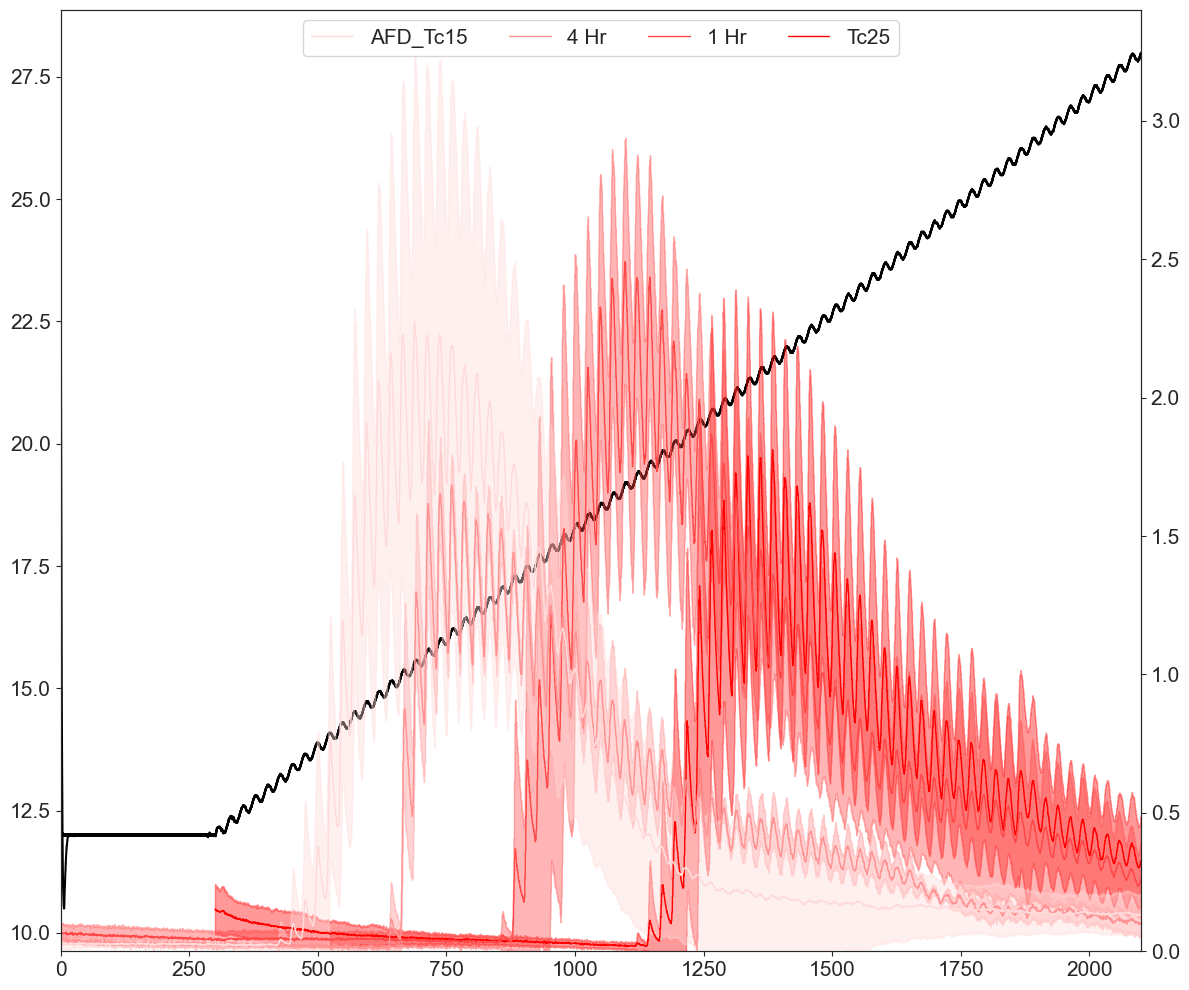

In [14]:
# No min-max scaling
plt.clf()
fig = plt.subplots(nrows=1,ncols=1,figsize=(12,10))

ax1 = plt.subplot(1,1,1)
ax1.plot(AFD_Tc15['Time'], AFD_Tc15['Temp'], 'k')
ax1.plot(AFD_Min240['Time'], AFD_Min240['Temp'], 'k')
ax1.plot(AFD_Min60['Time'], AFD_Min60['Temp'], 'k')
ax1.plot(AFD_Min0['Time'], AFD_Min0['Temp'], 'k')

ax1.set_xlim(min(AFD_Min240['Time']),max(AFD_Min240['Time']))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

ax2 = ax1.twinx()
color=iter(cm.bwr_r(np.linspace(0,1,8)))
ax2.plot(AFD_Min0['Time'][3000:], AFD_Min0['Mean_Delta'][3000:], c=next(color), lw=1, label='Tc25')
ax2.plot(AFD_Min60['Time'], AFD_Min60['Mean_Delta'], c=next(color), lw=1, label='1 Hr')
ax2.plot(AFD_Min240['Time'], AFD_Min240['Mean_Delta'], c=next(color), lw=1, label='4 Hr')
ax2.plot(AFD_Tc15['Time'], AFD_Tc15['Mean_Delta'], c=next(color), lw=1, label='AFD_Tc15')
handlesyep, labelsyep = ax2.get_legend_handles_labels()

ax2.legend(handles = reversed(handlesyep), labels=reversed(labelsyep), fontsize = 15, loc='upper center', ncol=7)
color=iter(cm.bwr_r(np.linspace(0,1,8)))
ax2.fill_between(AFD_Min0['Time'][3000:], AFD_Min0['Std_low_Delta'][3000:], AFD_Min0['Std_high_Delta'][3000:], color=next(color), alpha=0.4, lw=1)
ax2.fill_between(AFD_Min60['Time'], AFD_Min60['Std_low_Delta'], AFD_Min60['Std_high_Delta'], color=next(color), alpha=0.4, lw=1)
ax2.fill_between(AFD_Min240['Time'], AFD_Min240['Std_low_Delta'], AFD_Min240['Std_high_Delta'], color=next(color), alpha=0.4, lw=1)
ax2.fill_between(AFD_Tc15['Time'], AFD_Tc15['Std_low_Delta'], AFD_Tc15['Std_high_Delta'], color=next(color), alpha=0.4, lw=1)

ax2.set_ylim(0,3.4)
ax2.set_xlim(min(AFD_Min240['Time']),max(AFD_Min240['Time']))
plt.tick_params(axis='both', which='major', labelsize=15)
plt.tick_params(axis='both', which='minor', labelsize=15)

plt.tight_layout()

#lt.savefig('TcDownShiftExpt.png', dpi=600, bbox_inches='tight')
#plt.savefig('TcDownShiftExpt_NoMinMax.svg', dpi=600, bbox_inches='tight')
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

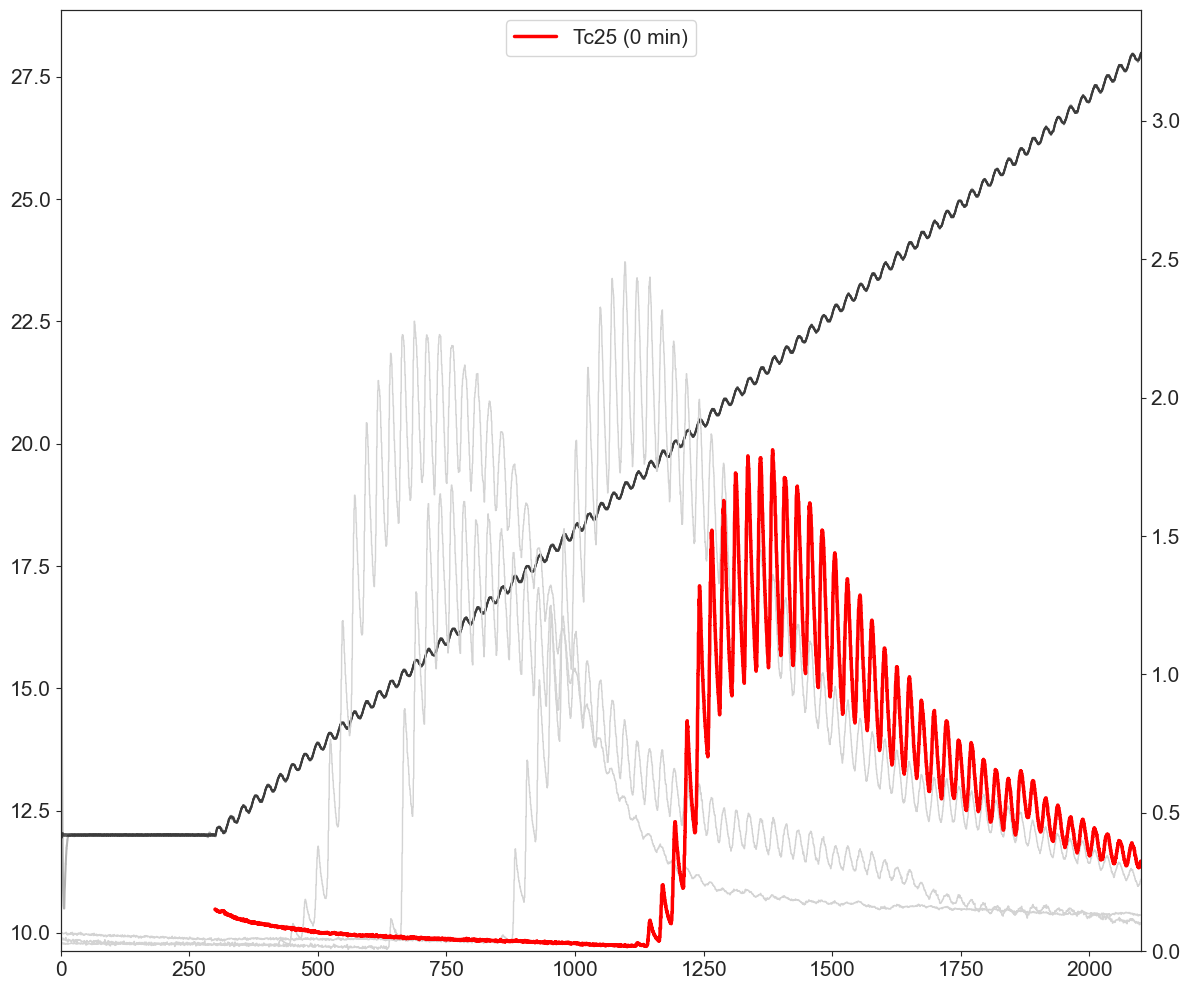

<Figure size 640x480 with 0 Axes>

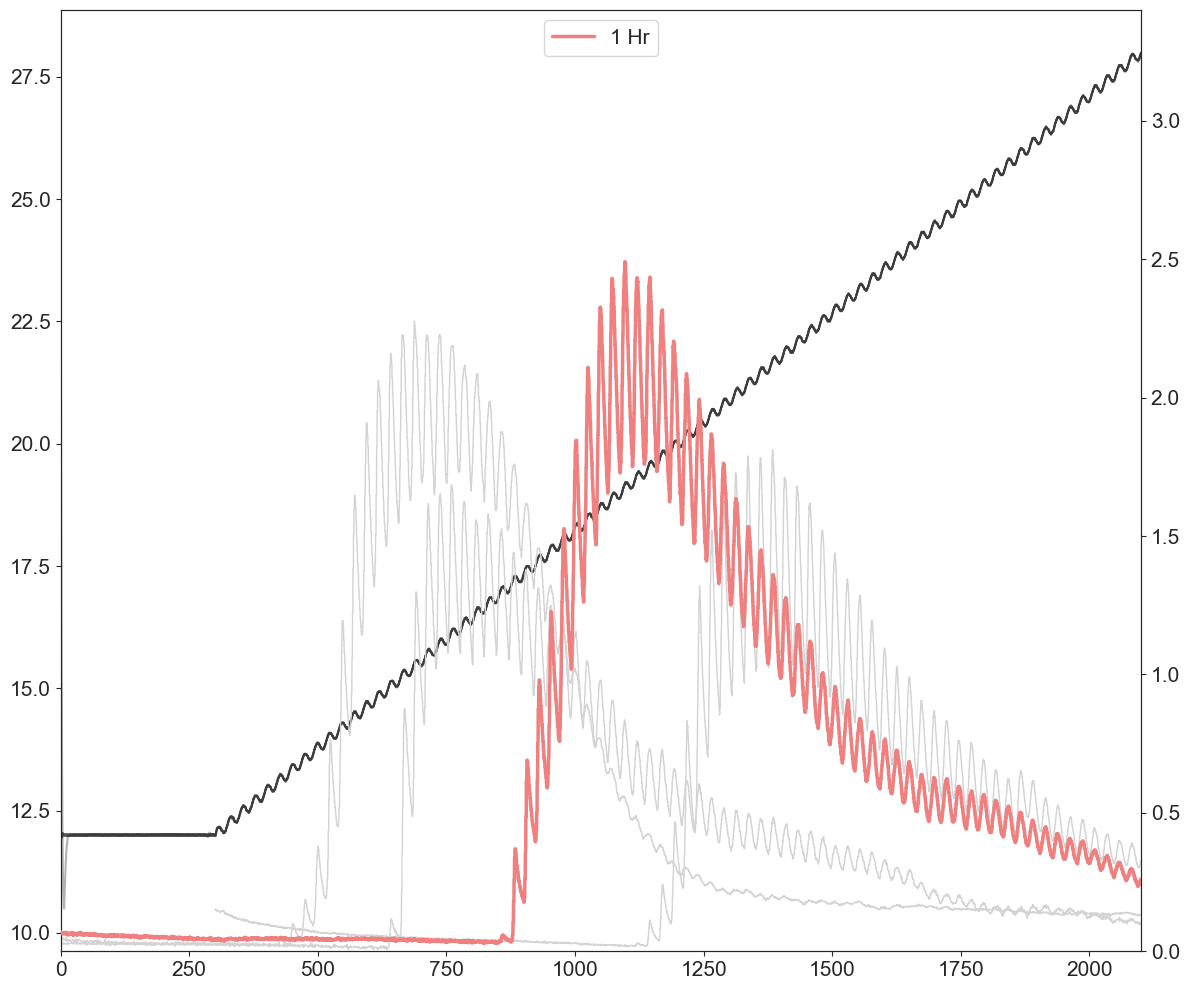

<Figure size 640x480 with 0 Axes>

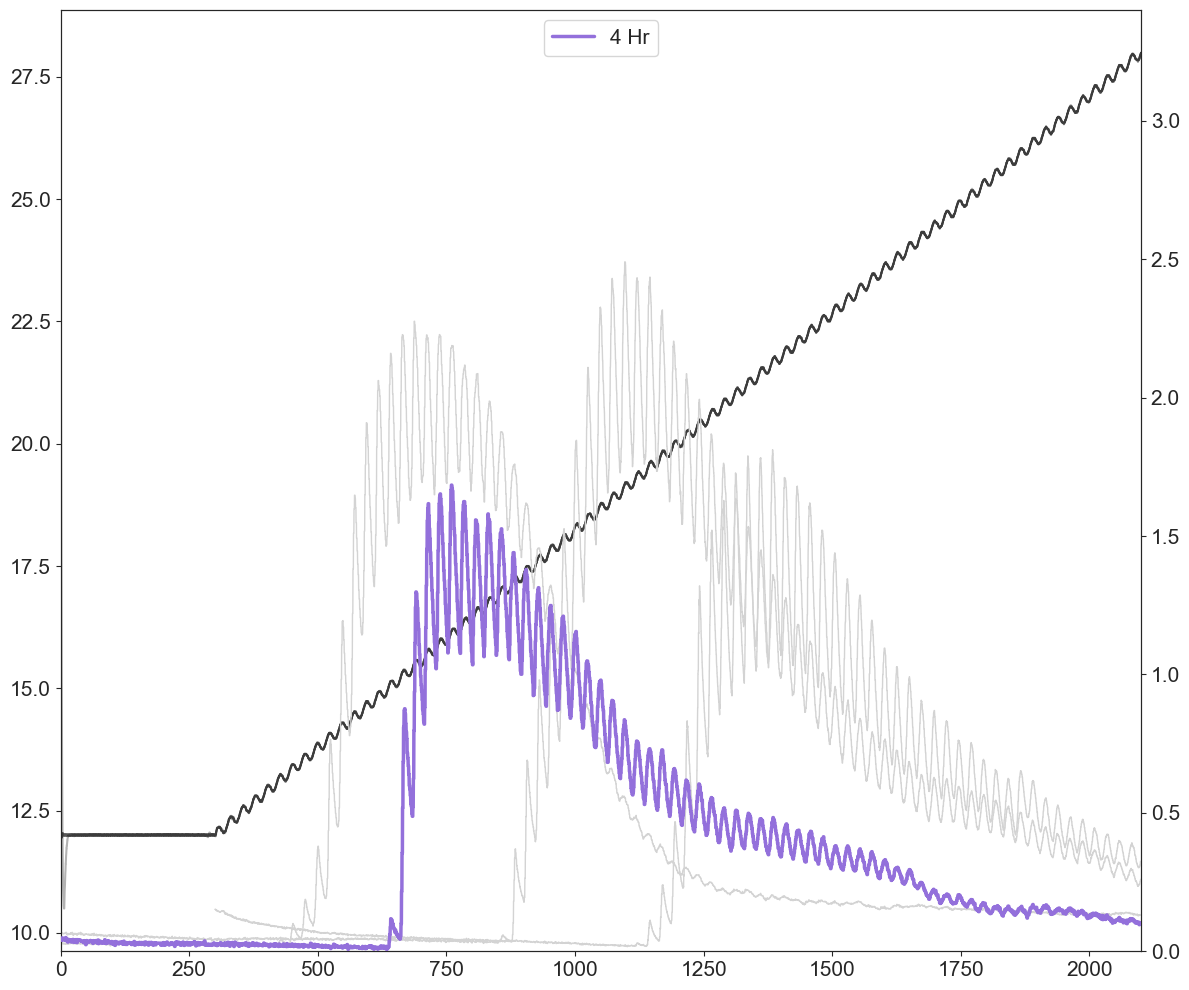

<Figure size 640x480 with 0 Axes>

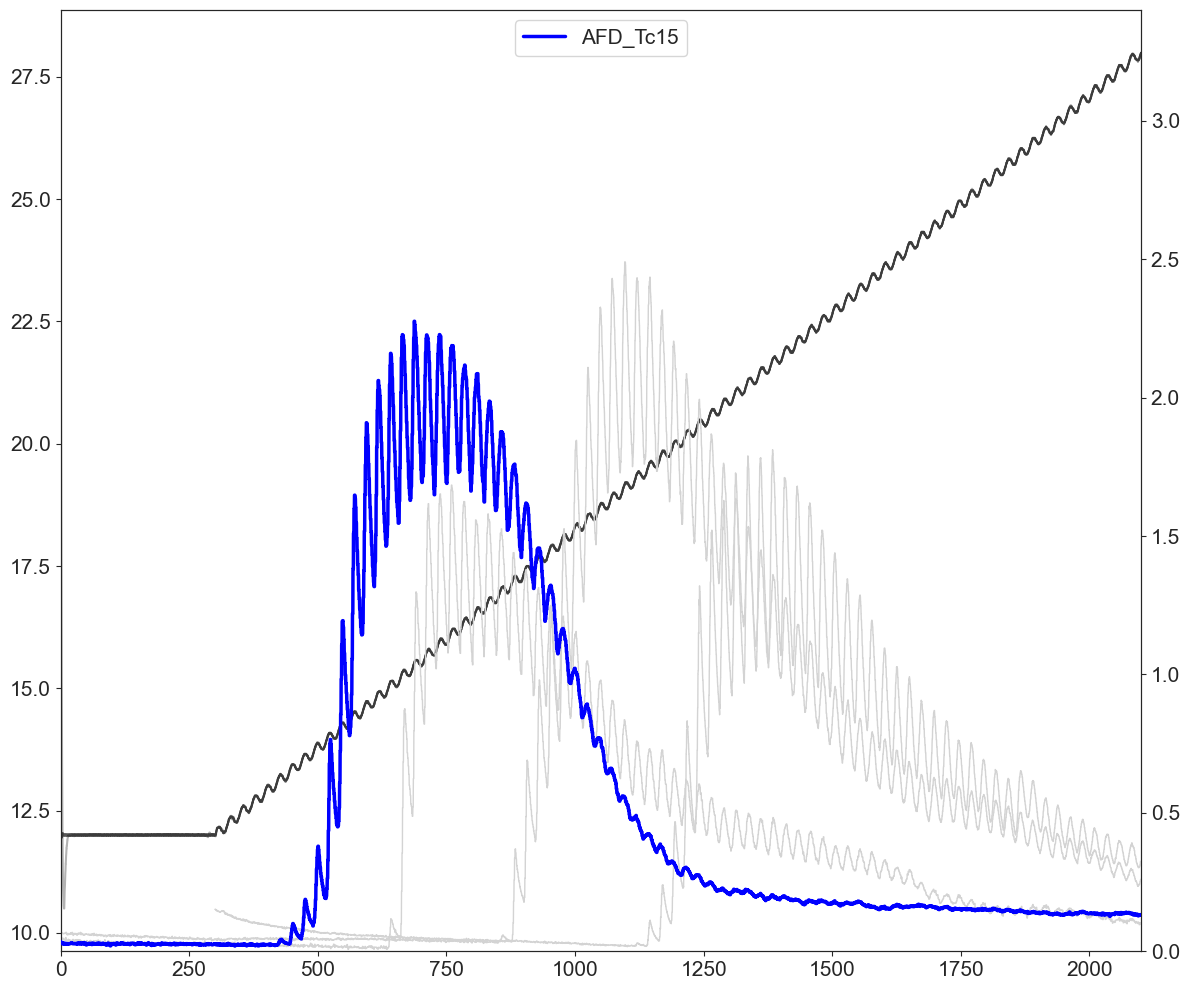

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the datasets and their highlighted styling
groups = [
    {'data': AFD_Min0, 'color': 'red', 'label': 'Tc25 (0 min)', 'slice': slice(3000, None)},
    {'data': AFD_Min60, 'color': 'lightcoral', 'label': '1 Hr', 'slice': slice(None)},
    {'data': AFD_Min240, 'color': 'mediumpurple', 'label': '4 Hr', 'slice': slice(None)},
    {'data': AFD_Tc15, 'color': 'blue', 'label': 'AFD_Tc15', 'slice': slice(None)}
]

for i, highlight_group in enumerate(groups):
    plt.clf()
    fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(12, 10))
    
    # --- Axis 1: Temperature Profile ---
    # Plotting temperature in black for all
    for g in groups:
        ax1.plot(g['data']['Time'], g['data']['Temp'], 'k', alpha=0.3)
    
    ax1.set_xlim(min(AFD_Min240['Time']), max(AFD_Min240['Time']))
    ax1.tick_params(axis='both', which='major', labelsize=15)

    # --- Axis 2: Calcium Dynamics (Mean Delta) ---
    ax2 = ax1.twinx()
    
    # 1. Plot background groups in gray (No error bars)
    for background_group in groups:
        d = background_group['data']
        s = background_group['slice']
        ax2.plot(d['Time'][s], d['Mean_Delta'][s], color='lightgray', lw=1, zorder=1)

    # 2. Plot the highlighted group (With color and error bars)
    target = highlight_group['data']
    t_color = highlight_group['color']
    t_label = highlight_group['label']
    t_slice = highlight_group['slice']
    
    # Plot mean trace
    ax2.plot(target['Time'][t_slice], target['Mean_Delta'][t_slice], 
             color=t_color, lw=2.5, label=t_label, zorder=3)


    # Styling and limits
    ax2.set_ylim(0, 3.4)
    ax2.set_xlim(min(AFD_Min240['Time']), max(AFD_Min240['Time']))
    ax2.legend(fontsize=15, loc='upper center')
    ax2.tick_params(axis='both', which='major', labelsize=15)
    
    plt.tight_layout()
    
    # Optional: Save each plot uniquely
    # plt.savefig(f'Highlight_{t_label.replace(" ", "_")}.png', dpi=300)
    
    plt.show()
    plt.close()

# Upshift

In [17]:
def extract_frameTimes_from_metadata(metadata_filename):
    frameTimes = []
    
    with open(metadata_filename) as f:
        metadata = json.load(f)
    f.close()
    
    if int(metadata['Summary']['MicroManagerVersion'][0]) == 1:
        print('MicroManager v1')
        hour = int(metadata['FrameKey-0-0-0']['Time'][11:13])
        minute = int(metadata['FrameKey-0-0-0']['Time'][14:16])
        second = int(metadata['FrameKey-0-0-0']['Time'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)-int(metadata['FrameKey-0-0-0']['ElapsedTime-ms'])
    elif int(metadata['Summary']['MicroManagerVersion'][0]) > 1:
        print('MicroManager v2 or greater')
        hour = int(metadata['Summary']['StartTime'][11:13])
        minute = int(metadata['Summary']['StartTime'][14:16])
        second = int(metadata['Summary']['StartTime'][17:19])
        start_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+int(metadata['Summary']['StartTime'][20:23])

    for i in range(len(metadata.keys())-1):
        frame_name = "FrameKey-"+str(i)+"-0-0"
        #print(frame_name, start_time + int(metadata[frame_name]['ElapsedTime-ms']))
        frameTimes.append(start_time + int(metadata[frame_name]['ElapsedTime-ms']))
            
    return frameTimes

def extract_temps_times_from_metadata(stim_filename):
    Stim_data = {}
    Stim_data['Temp'] = []
    Stim_data['Time'] = []
    with open(stim_filename, "r") as stim:
        if '/' in stim_filename:
            stim_filename = stim_filename.split('/')[-1]
            
        rep_to_time = stim_filename.split(".txt")[0].split("_")
        hour = int(rep_to_time[1][0]+rep_to_time[1][1])
        minute = int(rep_to_time[1][2]+rep_to_time[1][3])
        #second = int(rep_to_time[1][4]+rep_to_time[1][5])
        #ms = int(rep_to_time[2])
        #starting_time = (hour*60*60*1000)+(minute*60*1000)+(second*1000)+ms
        hour_min = (hour*60*60*1000)+(minute*60*1000)

        elapsed_time_check = 0
        elapsed_min = 0
        for line in stim:
            #print(line
            pieces = line.split("\t")
            if len(pieces) < 2 or len(pieces) > 4:
                continue
            else:
                Stim_data['Temp'].append(float(pieces[0]))

                sec = int(pieces[3].split(".")[0])
                ms = int(pieces[3].split(".")[1])
                elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                
                if (hour_min+elapsed_time) >= 86400000:
                    midnight_crossing = hour_min+elapsed_time
                    elapsed_time = midnight_crossing - 86400000
                    elapsed_time_check = -1
                    hour_min = 0
                    elapsed_min = 0

                if elapsed_time > elapsed_time_check:
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                elif elapsed_time <= elapsed_time_check:
                    elapsed_min += 1
                    elapsed_time = (elapsed_min*60*1000)+(sec*1000)+ms
                    Stim_data['Time'].append(hour_min+elapsed_time)
                    elapsed_time_check = elapsed_time
                else:
                    print('issue, something wrong')
    stim.close()
    return Stim_data

def align_Ca_to_stim(GCaMP_array, RFP_array, frameTimes, Stim):
    Stim_aligned_data = {}
    Stim_aligned_data['GCaMP'] = np.zeros((len(GCaMP_array),len(Stim['Time'])))
    Stim_aligned_data['RFP'] = np.zeros((len(RFP_array),len(Stim['Time'])))
    Stim_aligned_data['Time'] = []
    Stim_aligned_data['Temp'] = Stim['Temp']
    check = 1
    midnight_checker = 0
    for i in range(len(Stim['Time'])):
        if Stim['Time'][i-1] > 86340000 and Stim['Time'][i] < 60000 and midnight_checker == 0:
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
            midnight_checker = 1
        elif midnight_checker == 1: 
            Stim_aligned_data['Time'].append(Stim['Time'][i]+(86400000-Stim['Time'][0]))
        else:
            Stim_aligned_data['Time'].append(Stim['Time'][i]-Stim['Time'][0])
        if Stim['Time'][i] > max(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,(len(GCaMP_array[j,:])-1)]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,(len(RFP_array[j,:])-1)]
            print('missed end')
        elif Stim['Time'][i] < min(frameTimes):
            for j in range(len(GCaMP_array)):
                Stim_aligned_data['GCaMP'][j,i] = GCaMP_array[j,0]
                Stim_aligned_data['RFP'][j,i] = RFP_array[j,0]
            print('missed start')
        else:
            for j in range(check, len(frameTimes)):
                if frameTimes[j-1] < Stim['Time'][i] <= frameTimes[j]:
                    for k in range(len(GCaMP_array)):
                        Stim_aligned_data['GCaMP'][k,i] = GCaMP_array[k,j]
                        Stim_aligned_data['RFP'][k,i] = RFP_array[k,j]
                    check = j
                    break
    return Stim_aligned_data

def ratio_and_scale(GCaMP_Array, RFP_Array, RFP_check=True):
    Ratio = np.zeros(np.shape(GCaMP_Array))
    Scaled = np.zeros(np.shape(GCaMP_Array))
    Delta = np.zeros(np.shape(GCaMP_Array))
    
    if RFP_check == True:
        for i in range(len(GCaMP_Array)):
            for j in range(len(GCaMP_Array[i,:])):
                Ratio[i,j] = GCaMP_Array[i,j]/RFP_Array[i,j]
            min_rat = min(Ratio[i,:])
            for j in range(len(Ratio[i,:])):
                Delta[i,j] = (Ratio[i,j] - min_rat)/float(min_rat)
            Scaled[i,:] = minmax_scale(Ratio[i,:], feature_range=(0, 1))
    elif RFP_check == False:
        for i in range(len(GCaMP_Array)):
            Scaled[i,:] = minmax_scale(GCaMP_Array[i,:], feature_range=(0, 1))
            min_gcamp = min(GCaMP_Array[i,:])
            for j in range(len(GCaMP_Array[i,:])):
                Delta[i,j] = (GCaMP_Array[i,j] - min_gcamp)/float(min_gcamp)
    else:
        print('issue Scaling')
        
    return Ratio, Delta, Scaled

def find_temp_transition(Stim_aligned_data, start_search, temp_thresh):
    for i in reversed(range(start_search)):
        if Stim_aligned_data['Temp'][i]>=temp_thresh:
            start_index = i
            break
    #print(start_index)
    return start_index

def segment_data(Stim_aligned_data, start_index, stop_index, AIY=False):
    Segmented_data = {}
    Segmented_data['GCaMP'] = Stim_aligned_data['GCaMP'][:,start_index:stop_index]
    Segmented_data['RFP'] = Stim_aligned_data['RFP'][:,start_index:stop_index]
    Segmented_data['Scaled'] = Stim_aligned_data['Scaled'][:,start_index:stop_index]
    Segmented_data['Time'] = []
    for i in range(len(Stim_aligned_data['Time'][start_index:stop_index])):
        Segmented_data['Time'].append(Stim_aligned_data['Time'][start_index+i]-Stim_aligned_data['Time'][start_index])
    Segmented_data['Temp'] = Stim_aligned_data['Temp'][start_index:stop_index]
    
    if AIY == True:
        Segmented_data['Resp_Rate'] = Stim_aligned_data['Resp_Rate'][:,start_index:stop_index]
        Segmented_data['Resp'] = Stim_aligned_data['Resp'][:,start_index:stop_index]
    
    return Segmented_data

def combine_segments_calc_stats(Segment_list, AIY=False):
    Combined_data = {}
    Combined_data['GCaMP'] = np.concatenate([Seg_dict['GCaMP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['RFP'] = np.concatenate([Seg_dict['RFP'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Scaled'] = np.concatenate([Seg_dict['Scaled'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Delta'] = np.concatenate([Seg_dict['Delta'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Ratio'] = np.concatenate([Seg_dict['Ratio'] for Seg_dict in Segment_list], axis=0)
    Combined_data['Mean'] = []
    Combined_data['Std_high'] = []
    Combined_data['Std_low'] = []
    Combined_data['Mean_Delta'] = []
    Combined_data['Std_high_Delta'] = []
    Combined_data['Std_low_Delta'] = []
    Combined_data['Mean_Ratio'] = []
    Combined_data['Std_high_Ratio'] = []
    Combined_data['Std_low_Ratio'] = []
    for i in range(len(Combined_data['Scaled'][0,:])):
        Combined_data['Mean'].append(np.mean(Combined_data['Scaled'][:,i]))
        Combined_data['Std_high'].append(np.mean(Combined_data['Scaled'][:,i])+tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Std_low'].append(np.mean(Combined_data['Scaled'][:,i])-tstd(Combined_data['Scaled'][:,i]))
        Combined_data['Mean_Delta'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Delta'].append(np.mean(Combined_data['Delta'][:,i])+tstd(Combined_data['Delta'][:,i]))
        Combined_data['Std_low_Delta'].append(np.mean(Combined_data['Delta'][:,i])-tstd(Combined_data['Delta'][:,i]))
        Combined_data['Mean_Ratio'].append(np.mean(Combined_data['Delta'][:,i]))
        Combined_data['Std_high_Ratio'].append(np.mean(Combined_data['Ratio'][:,i])+tstd(Combined_data['Ratio'][:,i]))
        Combined_data['Std_low_Ratio'].append(np.mean(Combined_data['Ratio'][:,i])-tstd(Combined_data['Ratio'][:,i]))
    Combined_data['Time'] = []
    Combined_data['Temp'] = []
    for i in range(len(Segment_list[0]['Time'])):
        time_total_dum = 0
        time_count_dum = 0
        temp_total_dum = 0
        temp_count_dum = 0
        for j in range(len(Segment_list)):
            time_total_dum += Segment_list[j]['Time'][i]*len(Segment_list[j]['GCaMP'])
            time_count_dum += len(Segment_list[j]['GCaMP'])
            temp_total_dum += Segment_list[j]['Temp'][i]*len(Segment_list[j]['GCaMP'])
            temp_count_dum += len(Segment_list[j]['GCaMP'])
        Combined_data['Time'].append(time_total_dum/(time_count_dum*1000))
        Combined_data['Temp'].append(temp_total_dum/temp_count_dum)
        
    if AIY == True:
        Combined_data['Resp'] = np.concatenate([Seg_dict['Resp'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Resp_Rate'] = np.concatenate([Seg_dict['Resp_Rate'] for Seg_dict in Segment_list], axis=0)
        Combined_data['Mean_Resp_Rate'] = []
        for i in range(len(Combined_data['Resp_Rate'][0,:])):
            Combined_data['Mean_Resp_Rate'].append(np.mean(Combined_data['Resp_Rate'][:,i]))
            
    return Combined_data

def load_GCaMP_RFP_meta_stim(Rep_list, stim_list, cell, RFP_check=True, subcell='None'):
    # Possible kwargs: cell = '
    Aligned_data_list = []
    for i in range(len(Rep_list)):
        Rep_name = Rep_list[i]
        stim_name = stim_list[i]
        print(Rep_name)
        if subcell != 'None':
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+subcell+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_'+subcell+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))
        else:
            GCaMP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results.csv', header=None)))
            if RFP_check==True:
                RFP = np.transpose(np.array(pd.read_csv(Rep_name+'_Results_RFP.csv', header=None)))
            elif RFP_check==False:
                RFP = np.zeros(np.shape(GCaMP))

        frameTimes = extract_frameTimes_from_metadata(Rep_name+'_MMStack_Pos0_metadata.txt')
        #print(frameTimes[0:10]
        Stim = extract_temps_times_from_metadata(stim_name+'.txt')
        #print(Stim['Time'][0:10]

        Aligned_data = align_Ca_to_stim(GCaMP, RFP, frameTimes, Stim)
        Aligned_data['Ratio'], Aligned_data['Delta'], Aligned_data['Scaled'] = ratio_and_scale(Aligned_data['GCaMP'], Aligned_data['RFP'], RFP_check=RFP_check)

        if cell == 'AIY':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)

        if cell == 'AIY_Paired':
            Aligned_data['Resp'], Aligned_data['Resp_Rate'] = calc_AIY_responses(Aligned_data['Scaled'], threshold = 0.05, window = 300)
        
        Aligned_data_list.append(Aligned_data)
        print('Done')
        
    if cell == 'AFD':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list)
        Aligned_data_Combined['Deriv'], Aligned_data_Combined['Response_frame'], Aligned_data_Combined['Response_temp'] = find_AFD_deriv_and_response_thresh(Aligned_data_Combined)
    elif cell == 'AIY':
        Aligned_data_Combined = combine_segments_calc_stats(Aligned_data_list, AIY=True)
        
    return Aligned_data_Combined

def calc_AIY_responses(Scaled_data, threshold = 0.05, window = 300, back=True):
    AIY_Deriv = np.zeros(np.shape(Scaled_data))
    AIY_Response = np.zeros(np.shape(Scaled_data))
    AIY_Resp_Rate = np.zeros(np.shape(Scaled_data))
        
        
    for i in range(len(Scaled_data)):
        AIY_Deriv[i,1:] = np.diff(Scaled_data[i,:])

        check = 0
        for j in range(len(AIY_Deriv[i,:])):
            if AIY_Deriv[i,j] > threshold and check == 0:
                AIY_Response[i,j] = 1
                check = 1
            elif AIY_Deriv[i,j] < threshold and check == 1:
                check = 0
            else:
                continue

        for j in range(len(AIY_Response[i,:])):
            if back == True:
                if j-(2*window) < 0:
                    #Tc20_Combined['AIY'][key]['Resp_Rate'][i,j] = np.sum(Tc20_Combined['AIY'][key]['Response'][i,0:j])*60/float(j/10)
                    AIY_Resp_Rate[i,j] = np.nan
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-(2*window):j])
            else:
                if j-window < 0:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,0:j+window])*60/float((j+window)*60/10)
                elif j+window > len(AIY_Response[i,:]):
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:])
                else:
                    AIY_Resp_Rate[i,j] = np.sum(AIY_Response[i,j-window:j+window])

        #Tc20_Combined['AIY'][key]['Mean_Resp_Rate'] = []
        #for i in range(len(Tc20_Combined['AIY'][key]['Resp_Rate'][0,:])):
        #    Tc20_Combined['AIY'][key]['Mean_Resp_Rate'].append(np.mean(Tc20_Combined['AIY'][key]['Resp_Rate'][:,i]))
            
    return AIY_Response, AIY_Resp_Rate

def find_AFD_deriv_and_response_thresh(AFD_data, threshold = 0.01, start_frame = 600):
    Deriv = [0]
    Deriv.extend(list(np.diff(AFD_data['Mean'])))
    for i in range(len(Deriv[start_frame:])):
        if Deriv[start_frame+i] > threshold:
            Response_frame = start_frame+i
            Response_temp = AFD_data['Temp'][Response_frame]
            break
    return Deriv, Response_frame, Response_temp

In [18]:
pref = 'Temp_Upshift_15_25/Data/'
Tc15_WT_meta = [pref + '101821_3055_12deghold_Sinusoid_Tc15_A_1']
Tc15_WT_stim = [pref + '101821_150239_097']
Tc15_WT_Soma = load_GCaMP_RFP_meta_stim(Tc15_WT_meta, Tc15_WT_stim, 'AFD', subcell='Soma')

min5_WT_meta = [pref + '110921_3055_12deghold_Sinusoid_Tc15_5min25_B_1']
min5_WT_stim = [pref + '110921_152004_093']
min5_WT_Soma = load_GCaMP_RFP_meta_stim(min5_WT_meta, min5_WT_stim, 'AFD', subcell='Soma')

min20_WT_meta = [pref + '102921_3055_12deghold_Sinusoid_Tc15_20min25_A_1']
min20_WT_stim = [pref + '102921_151935_651']
min20_WT_Soma = load_GCaMP_RFP_meta_stim(min20_WT_meta, min20_WT_stim, 'AFD', subcell='Soma')

min60_WT_meta = [pref + '110121_3055_12deghold_Sinusoid_Tc15_60min25_A_1']
min60_WT_stim = [pref + '110121_152506_492']
min60_WT_Soma = load_GCaMP_RFP_meta_stim(min60_WT_meta, min60_WT_stim, 'AFD', subcell='Soma')

Tc25_WT_meta = [pref + '101821_3055_12deghold_Sinusoid_Tc25_A_1']
Tc25_WT_stim = [pref + '101821_202739_374']
Tc25_WT_Soma = load_GCaMP_RFP_meta_stim(Tc25_WT_meta, Tc25_WT_stim, 'AFD', subcell='Soma')


Temp_Upshift_15_25/Data/101821_3055_12deghold_Sinusoid_Tc15_A_1
MicroManager v1
Done
Temp_Upshift_15_25/Data/110921_3055_12deghold_Sinusoid_Tc15_5min25_B_1
MicroManager v1
Done
Temp_Upshift_15_25/Data/102921_3055_12deghold_Sinusoid_Tc15_20min25_A_1
MicroManager v1
Done
Temp_Upshift_15_25/Data/110121_3055_12deghold_Sinusoid_Tc15_60min25_A_1
MicroManager v1
Done
Temp_Upshift_15_25/Data/101821_3055_12deghold_Sinusoid_Tc25_A_1
MicroManager v1
Done


In [19]:
print( len(Tc25_WT_Soma['GCaMP']))
print( len(Tc15_WT_Soma['GCaMP']))
print( len(min5_WT_Soma['GCaMP']))
print( len(min20_WT_Soma['GCaMP']))
print( len(min60_WT_Soma['GCaMP']))

9
5
10
12
10


<Figure size 640x480 with 0 Axes>

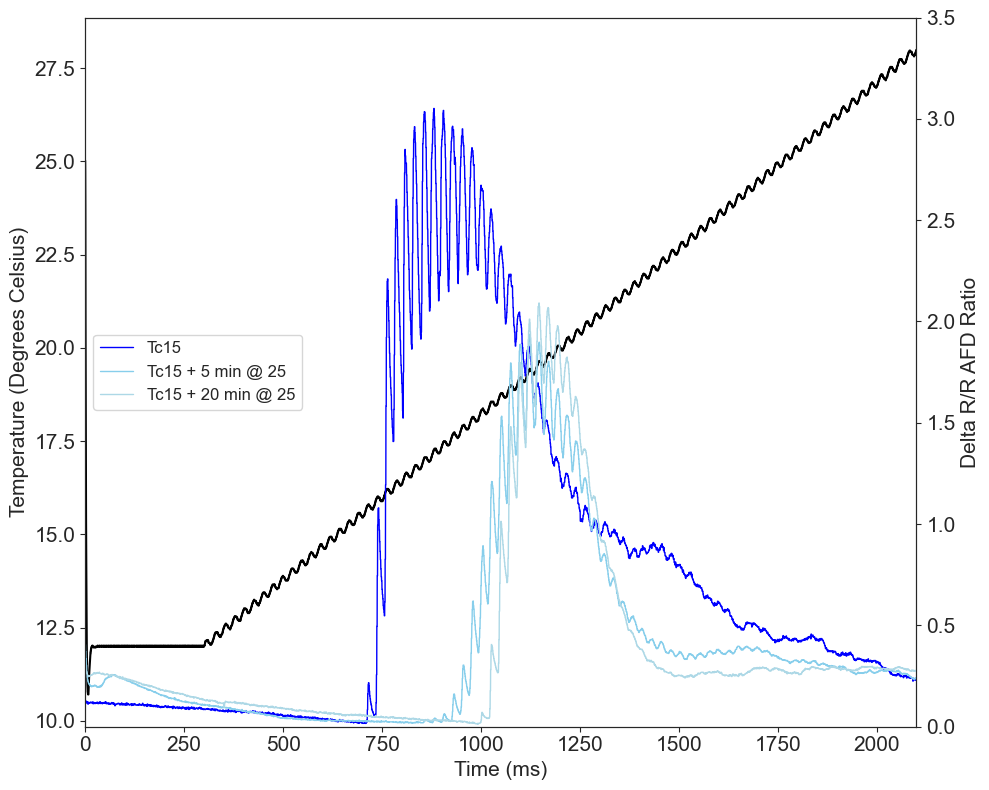

<Figure size 640x480 with 0 Axes>

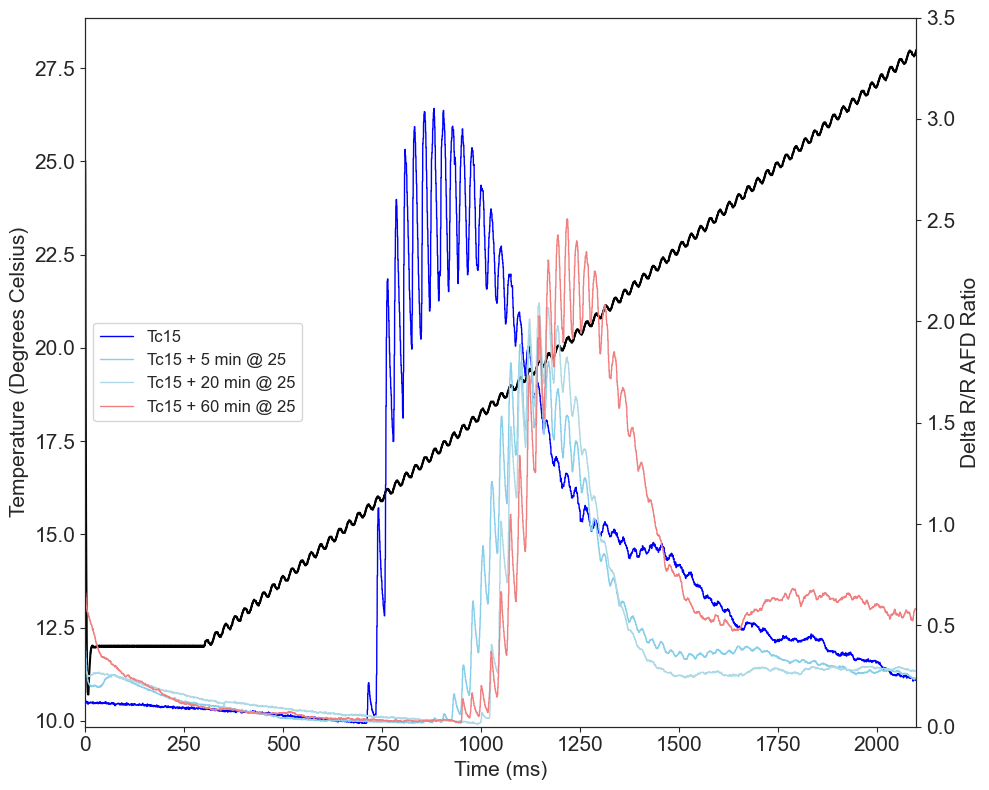

In [28]:
import matplotlib.pyplot as plt

# Define color palette for consistency
colors = {
    'Tc15': 'blue',
    'min5': 'skyblue',      # Lighter blue
    'min20': 'lightblue',   # Much lighter blue
    'min60': 'lightcoral'    # Soft red
}

# --- PLOT 1: Tc15 and early exposure groups ---
plt.clf()
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))

# Temperature Stimulus
ax1.plot(min5_WT_Soma['Time'], min5_WT_Soma['Temp'], 'k', label='Temp Stimulus')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
ax1.set_xlabel('Time (ms)', fontsize=15)
ax1.set_xlim(min(min20_WT_Soma['Time']), max(min20_WT_Soma['Time']))
ax1.tick_params(axis='both', which='major', labelsize=15)

# Calcium Dynamics (AFD Ratio)
ax2 = ax1.twinx()
ax2.plot(Tc15_WT_Soma['Time'], Tc15_WT_Soma['Mean_Delta'], c=colors['Tc15'], lw=1, label='Tc15')
ax2.plot(min5_WT_Soma['Time'], min5_WT_Soma['Mean_Delta'], c=colors['min5'], lw=1, label='Tc15 + 5 min @ 25')
ax2.plot(min20_WT_Soma['Time'], min20_WT_Soma['Mean_Delta'], c=colors['min20'], lw=1, label='Tc15 + 20 min @ 25')

ax2.set_ylabel('Delta R/R AFD Ratio', fontsize=15)
ax2.set_ylim(0, 3.5)
ax2.legend(fontsize=12, loc='center left')
ax2.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()


# --- PLOT 2: All groups including Tc25 ---
plt.clf()
fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(10, 8))

# Temperature Stimulus
ax1.plot(min5_WT_Soma['Time'], min5_WT_Soma['Temp'], 'k', label='Temp Stimulus')
ax1.set_ylabel('Temperature (Degrees Celsius)', fontsize=15)
ax1.set_xlabel('Time (ms)', fontsize=15)
ax1.set_xlim(min(min20_WT_Soma['Time']), max(min20_WT_Soma['Time']))
ax1.tick_params(axis='both', which='major', labelsize=15)

# Calcium Dynamics (AFD Ratio)
ax2 = ax1.twinx()
ax2.plot(Tc15_WT_Soma['Time'], Tc15_WT_Soma['Mean_Delta'], c=colors['Tc15'], lw=1, label='Tc15')
ax2.plot(min5_WT_Soma['Time'], min5_WT_Soma['Mean_Delta'], c=colors['min5'], lw=1, label='Tc15 + 5 min @ 25')
ax2.plot(min20_WT_Soma['Time'], min20_WT_Soma['Mean_Delta'], c=colors['min20'], lw=1, label='Tc15 + 20 min @ 25')
ax2.plot(min60_WT_Soma['Time'], min60_WT_Soma['Mean_Delta'], c=colors['min60'], lw=1, label='Tc15 + 60 min @ 25')

ax2.set_ylabel('Delta R/R AFD Ratio', fontsize=15)
ax2.set_ylim(0, 3.5)
ax2.legend(fontsize=12, loc='center left')
ax2.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

# Oscillation Analysis: Prominence and Gain Calculation

In [51]:
import numpy as np
from scipy.signal import find_peaks, peak_prominences, peak_widths
import matplotlib.pyplot as plt


def plot_afd_calcium_analysis(
    Time,
    Temp,
    DeltaR,
    minProm=0.4,
    minPeakDist_sec=15,
    deriv_pre_frames=51,
    color='b',
    save=None
):
    """
    Analyze AFD calcium traces and estimate local gain.

    Gain is defined as:

        peak prominence / mean positive temperature derivative

    where the derivative is averaged over the preceding
    `deriv_pre_frames` immediately before each detected peak.

    Parameters
    ----------
    Time : array-like
    Temp : array-like
    DeltaR : array-like
    minProm : float
        Minimum peak prominence.
    minPeakDist_sec : float
        Minimum separation between peaks (seconds).
    deriv_pre_frames : int
        Number of frames preceding each peak used to compute
        mean positive temperature derivative.
    color : str
    save : str or None
    """

    # ------------------------------------------------------------
    # 1. Data preparation
    # ------------------------------------------------------------
    Time = np.asarray(Time, dtype=float)
    Temp = np.asarray(Temp, dtype=float)
    DeltaR = np.asarray(DeltaR, dtype=float)

    y = DeltaR.copy()

    # shift upward if trace contains negative values
    y_min = np.min(y)
    if y_min < 0:
        y = y - y_min

    dt_sec = np.mean(np.diff(Time))
    if dt_sec <= 0:
        raise ValueError("Time array must be increasing.")

    Temp_deriv = np.gradient(Temp, Time)

    minPeakDist_pts = int(np.ceil(minPeakDist_sec / dt_sec))

    # ------------------------------------------------------------
    # 2. Peak detection
    # ------------------------------------------------------------
    locs, properties = find_peaks(
        y,
        prominence=minProm,
        distance=minPeakDist_pts
    )

    pks = y[locs]

    # prominence window for peak detection only
    wlen_points = 601
    if wlen_points % 2 == 0:
        wlen_points += 1

    proms = peak_prominences(y, locs, wlen=wlen_points)[0]
    widths = peak_widths(y, locs, rel_height=0.5)[0]

    # ------------------------------------------------------------
    # 3. Local gain estimate
    # ------------------------------------------------------------
    local_temp_derivs = []
    gains = []

    eps = 1e-6

    for peak_idx, prom in zip(locs, proms):

        left = max(0, peak_idx - deriv_pre_frames)
        right = peak_idx

        local_deriv = Temp_deriv[left:right]

        # positive heating only
        pos_deriv = local_deriv[local_deriv > 0]

        if len(pos_deriv) > 0:
            mean_pos_deriv = np.mean(pos_deriv)
        else:
            mean_pos_deriv = np.nan

        local_temp_derivs.append(mean_pos_deriv)

        if np.isfinite(mean_pos_deriv) and mean_pos_deriv > eps:
            gains.append(prom / mean_pos_deriv)
        else:
            gains.append(np.nan)

    local_temp_derivs = np.asarray(local_temp_derivs)
    gains = np.asarray(gains)

    # ------------------------------------------------------------
    # 4. Plotting
    # ------------------------------------------------------------
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.suptitle('AFD Calcium Gain Analysis', fontsize=16)

    def setup_temp_axis(ax):
        ax.plot(Time, Temp, '-k', linewidth=1.2)
        ax.set_ylabel('Temperature (C)', color='k', fontsize=12)
        ax.tick_params(axis='y', labelcolor='k')
        ax.set_ylim(np.min(Temp), np.max(Temp))
        ax.grid(False)
        ax.spines['right'].set_visible(False)
        return ax.twinx()

    # ------------------------------------------------------------
    # Panel 1: trace and peaks
    # ------------------------------------------------------------
    ax1_twin = setup_temp_axis(axes[0])

    ax1_twin.plot(Time, y, '-', color=color, linewidth=1.2)
    ax1_twin.plot(
        Time[locs],
        pks,
        'o',
        color=color,
        markerfacecolor=color
    )

    ax1_twin.set_ylabel('GCaMP (ΔR/R)', color=color, fontsize=12)
    ax1_twin.tick_params(axis='y', labelcolor=color)
    ax1_twin.set_ylim(0, np.max(y) * 1.1)

    axes[0].set_title('Trace and Peaks')

    # ------------------------------------------------------------
    # Panel 2: peak height
    # ------------------------------------------------------------
    ax2_twin = setup_temp_axis(axes[1])

    markerline, stemlines, baseline = ax2_twin.stem(
        Time[locs],
        pks,
        basefmt=" "
    )

    plt.setp(markerline, color=color)
    plt.setp(stemlines, color=color)

    ax2_twin.set_ylabel('Peak Height (ΔR/R)', color=color, fontsize=12)
    ax2_twin.tick_params(axis='y', labelcolor=color)

    if len(pks) > 0:
        ax2_twin.set_ylim(0, np.max(pks) * 1.2)

    # ------------------------------------------------------------
    # Panel 3: peak prominence
    # ------------------------------------------------------------
    ax3_twin = setup_temp_axis(axes[2])

    markerline, stemlines, baseline = ax3_twin.stem(
        Time[locs],
        proms,
        basefmt=" "
    )

    plt.setp(markerline, color=color)
    plt.setp(stemlines, color=color)

    ax3_twin.set_ylabel('Prominence (ΔR/R)', color=color, fontsize=12)
    ax3_twin.tick_params(axis='y', labelcolor=color)

    if len(proms) > 0:
        ax3_twin.set_ylim(0, np.max(proms) * 1.2)

    # ------------------------------------------------------------
    # Panel 4: gain
    # ------------------------------------------------------------
    ax4_twin = setup_temp_axis(axes[3])

    valid = np.isfinite(gains)

    if np.sum(valid) > 0:
        markerline, stemlines, baseline = ax4_twin.stem(
            Time[locs][valid],
            gains[valid],
            basefmt=" "
        )

        plt.setp(markerline, color=color)
        plt.setp(stemlines, color=color)

        ax4_twin.set_ylim(0, np.nanmax(gains) * 1.2)

    ax4_twin.set_ylabel('Gain (ΔR/R)/(°C/s)', color=color, fontsize=12)
    ax4_twin.tick_params(axis='y', labelcolor=color)

    axes[3].set_xlabel('Time (s)', fontsize=12)

    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=600, bbox_inches='tight')

    plt.show()

    # ------------------------------------------------------------
    # 5. Summary
    # ------------------------------------------------------------
    print("\n--- Analysis Summary ---")

    if len(pks) > 0:
        print(f"Total Peaks Found: {len(pks)}")
        print(f"Mean Peak Height: {np.mean(pks):.3f} ΔR/R")
        print(f"Mean Peak Prominence: {np.mean(proms):.3f} ΔR/R")
        print(f"Mean Peak Width: {np.mean(widths):.2f} points")

        valid_gain = gains[np.isfinite(gains)]

        if len(valid_gain) > 0:
            print(f"Mean Gain: {np.mean(valid_gain):.3f} (ΔR/R)/(°C/s)")
        else:
            print("Mean Gain: could not be estimated")

    else:
        print("No significant peaks found.")

    return {
        'peak_indices': locs,
        'peak_heights': pks,
        'prominences': proms,
        'local_temp_derivs': local_temp_derivs,
        'gains': gains
    }

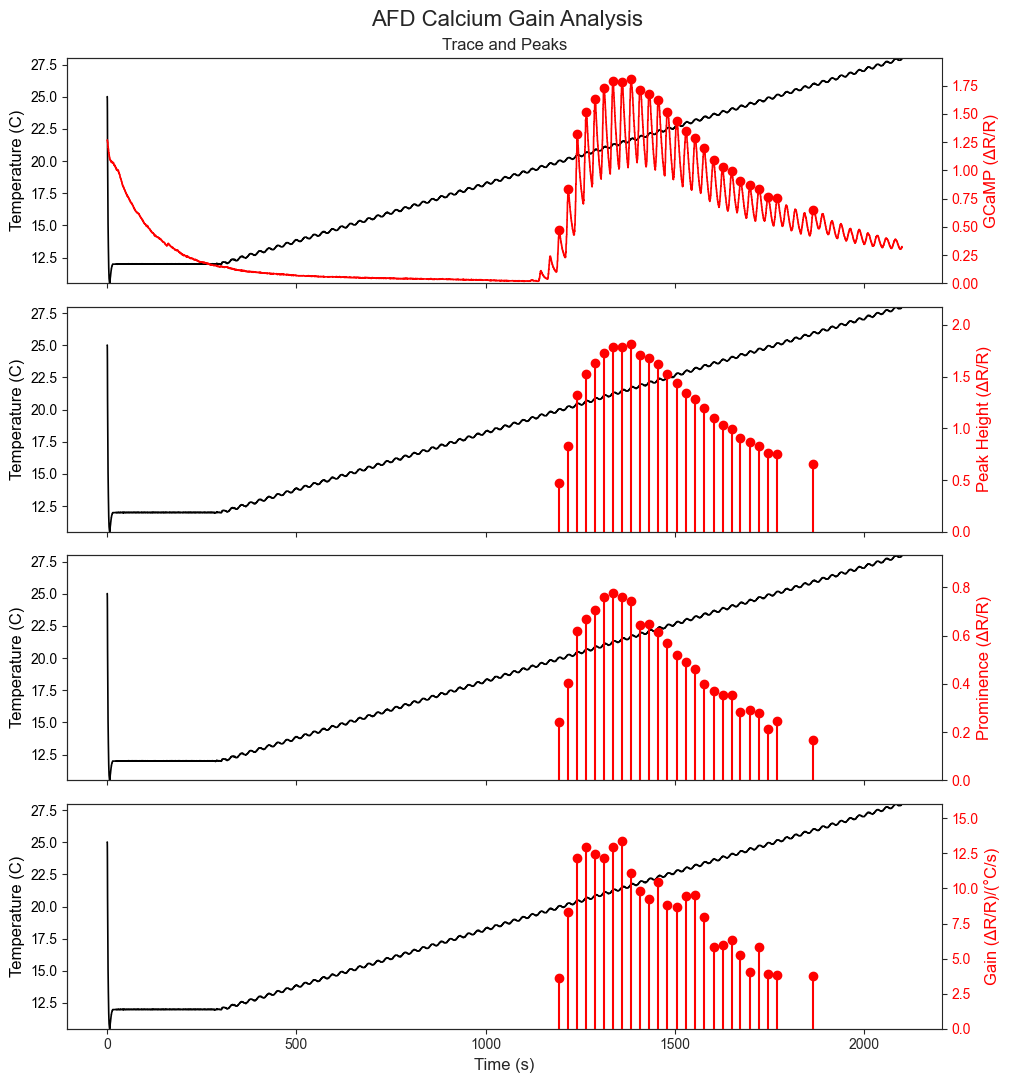


--- Analysis Summary ---
Total Peaks Found: 26
Mean Peak Height: 1.253 ΔR/R
Mean Peak Prominence: 0.484 ΔR/R
Mean Peak Width: 120.58 points
Mean Gain: 8.380 (ΔR/R)/(°C/s)


{'peak_indices': array([11942, 12177, 12417, 12657, 12888, 13117, 13357, 13607, 13838,
        14068, 14318, 14558, 14798, 15048, 15288, 15537, 15767, 16017,
        16257, 16497, 16727, 16982, 17217, 17447, 17697, 18657]),
 'peak_heights': array([0.46802659, 0.83260841, 1.32009232, 1.52098357, 1.62834616,
        1.72789256, 1.78949026, 1.78273511, 1.81165545, 1.7112692 ,
        1.68033812, 1.6195318 , 1.52143224, 1.43923951, 1.34539454,
        1.28686407, 1.19602289, 1.09521184, 1.02767269, 0.99162371,
        0.90688598, 0.86957991, 0.8326701 , 0.76249624, 0.75386364,
        0.65195377]),
 'prominences': array([0.24041102, 0.40476875, 0.61763038, 0.66683428, 0.70562496,
        0.75975326, 0.7776495 , 0.75871236, 0.74347955, 0.6430933 ,
        0.64836815, 0.6163766 , 0.56886796, 0.5204125 , 0.4895423 ,
        0.46227156, 0.39882951, 0.37005176, 0.35486268, 0.35186061,
        0.28280566, 0.29232021, 0.28081063, 0.21063677, 0.24538735,
        0.16898549]),
 'local_temp_derivs':

In [52]:
color=iter(cm.bwr_r(np.linspace(0,1,8)))
dir = 'Peak_Height_Prominence_Analysis/'
Time_Min0 = AFD_Min0['Time']
Temp_Min0 = AFD_Min0['Temp']
DeltaR_Min0 = AFD_Min0['Mean_Delta']
save = None
plot_afd_calcium_analysis(Time_Min0, Temp_Min0, DeltaR_Min0, minProm=0.2, minPeakDist_sec=15, color=next(color), save = save)

